In [81]:
#pip install pandas numpy matplotlib seaborn xgboost scikit-learn


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# XGBoost and ML libraries
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ndcg_score

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✓ All packages imported successfully")

✓ All packages imported successfully


In [82]:


# SET FILE PATH HERE
file_path = "full_market_data.csv" 

# Load data
print("Loading data...")
df = pd.read_csv(file_path)

# Convert tradedate to datetime
df['tradedate'] = pd.to_datetime(df['tradedate'])

# Sort by fid and tradedate to ensure proper time series
df = df.sort_values(['fid', 'tradedate']).reset_index(drop=True)

# Basic data inspection
print(f"\n✓ Data loaded successfully")
print(f"Shape: {df.shape}")
print(f"Date range: {df['tradedate'].min()} to {df['tradedate'].max()}")
print(f"Number of unique stocks: {df['fid'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Loading data...

✓ Data loaded successfully
Shape: (1843151, 14)
Date range: 2009-12-31 00:00:00 to 2020-01-01 00:00:00
Number of unique stocks: 903

Columns: ['tradedate', 'open', 'high', 'low', 'close', 'previous', 'traded_volume', 'traded_value', 'num_trades', 'mcap', 'fid', 'gics_sector', 'in_NSE500', 'cap_classification']

First few rows:
   tradedate     open     high      low    close  previous  traded_volume  \
0 2009-12-31 878.0000 883.9000 867.3500 872.4500       NaN         561526   
1 2010-01-04 870.0000 920.0000 870.0000 913.6000       NaN         852434   
2 2010-01-05 920.5500 926.4000 898.0500 901.7500       NaN         439209   
3 2010-01-06 904.5000 912.5000 895.3500 907.6000       NaN         517109   
4 2010-01-07 910.0000 926.0000 905.6500 913.3500       NaN         403862   

   traded_value  num_trades       mcap  fid  gics_sector  in_NSE500  \
0   491878.0000       12386 16379.4000    6      15.0000       True   
1   766253.0000       24562 17151.9000    6      

In [83]:
STRATEGY_CONFIG = {
    # Capital and Costs
    'initial_capital': 5_000_000,           # ₹50 lakhs starting capital
    'transaction_cost_rate': 0.00288,       # 0.288% per side (0.576% round-trip)
    
    # Portfolio Construction
    'min_positions': 1,                    # Minimum number of holdings
    'max_positions': 6,                    # Maximum number of holdings
    'max_single_position': 0.10,            # 10% maximum per stock, normalised maximum wieght = 25%
    'max_sector_concentration': 0.30,       # 30% maximum per sector
    
    # Risk Management
    'stop_loss_threshold': 0.35,            # 35% stop-loss trigger
    
    # Data Periods (STRATEGY FILE)
    'train_start_date': '2010-01-01',
    'train_end_date': '2020-12-31',
    
    # Feature Engineering
    'min_liquidity': 100_000,               # Minimum volume filter
    'min_price': 20,                        # Minimum price filter (₹)
    'forward_return_period': 63,            # Target calculation period (days)
    
    # Rebalancing
    'rebalance_frequency': 'Q',             # Quarterly rebalancing
    
    # XGBoost Parameters
    'xgb_params': {
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1,
        'learning_rate': 0.049314474646487784,
        'max_depth': 7,
        'n_estimators': 150,
        'subsample': 0.6523169645149013,
        'colsample_bytree': 0.6648186060994704,
        'reg_alpha': 0.011468801180923954,
        'reg_lambda': 1.1145025899481034,
        'objective': 'rank:pairwise'
    }
}

In [84]:
# Data validation
print("Performing data validation...\n")

# Check for negative or zero prices
invalid_prices = df[(df['close'] <= 0) | (df['open'] <= 0) |
                     (df['high'] <= 0) | (df['low'] <= 0)]
print(f"Invalid price rows (≤0): {len(invalid_prices)}")

# Check for high > low consistency
invalid_hl = df[df['high'] < df['low']]
print(f"Invalid high/low rows: {len(invalid_hl)}")

# Check for negative volumes
invalid_vol = df[(df['traded_volume'] < 0) | (df['traded_value'] < 0) |
                  (df['num_trades'] < 0)]
print(f"Invalid volume rows: {len(invalid_vol)}")

# Remove invalid data
df = df[
    (df['close'] > 0) &
    (df['open'] > 0) &
    (df['high'] > 0) &
    (df['low'] > 0) &
    (df['high'] >= df['low']) &
    (df['traded_volume'] >= 0) &
    (df['traded_value'] >= 0) &
    (df['num_trades'] >= 0)
].copy()

print(f"\n✓ Data after cleaning: {df.shape}")

# Create a copy for feature engineering
df_processed = df.copy()

Performing data validation...

Invalid price rows (≤0): 0
Invalid high/low rows: 0
Invalid volume rows: 0



✓ Data after cleaning: (1843151, 14)


In [85]:
def calculate_price_features(df):
    """
    Calculate momentum, trend, and volatility features
    Prevents look-ahead bias by using only historical data
    """
    print("Calculating price-based features...")

    df = df.sort_values(['fid', 'tradedate']).copy()

    # Daily returns (for volatility calculation)
    df['daily_return'] = df.groupby('fid')['close'].pct_change()

    # === MOMENTUM FEATURES (Rate of Change) ===
    # Using close-to-close returns, shifted to avoid look-ahead
    df['ROC_1M'] = df.groupby('fid')['close'].pct_change(periods=21)  # 1 month
    df['ROC_3M'] = df.groupby('fid')['close'].pct_change(periods=63)  # 3 months
    df['ROC_6M'] = df.groupby('fid')['close'].pct_change(periods=126) # 6 months
    df['ROC_12M'] = df.groupby('fid')['close'].pct_change(periods=252) # 12 months

    # 12-1 momentum (skip last month for mean reversion)
    df['ROC_12_1M'] = (df.groupby('fid')['close'].shift(21) /
                        df.groupby('fid')['close'].shift(252) - 1)

    # === MOVING AVERAGES ===
    df['SMA_20'] = df.groupby('fid')['close'].transform(lambda x: x.shift(1).rolling(20, min_periods=20).mean())
    df['SMA_50'] = df.groupby('fid')['close'].transform(lambda x: x.shift(1).rolling(50, min_periods=50).mean())
    df['SMA_200'] = df.groupby('fid')['close'].transform(lambda x: x.shift(1).rolling(200, min_periods=200).mean())

    # Distance from moving averages
    df['Dist_SMA20'] = (df['close'] / df['SMA_20']) - 1
    df['Dist_SMA50'] = (df['close'] / df['SMA_50']) - 1
    df['Dist_SMA200'] = (df['close'] / df['SMA_200']) - 1

    # === VOLATILITY FEATURES ===
    # Average True Range (ATR)
    df['high_low'] = df['high'] - df['low']
    df['high_close'] = abs(df['high'] - df.groupby('fid')['close'].shift(1))
    df['low_close'] = abs(df['low'] - df.groupby('fid')['close'].shift(1))
    df['true_range'] = df[['high_low', 'high_close', 'low_close']].max(axis=1)
    df['ATR_14'] = df.groupby('fid')['true_range'].transform(
        lambda x: x.shift(1).rolling(14, min_periods=14).mean()
    )

    # Normalized ATR (NATR) - volatility as % of price
    df['NATR_14'] = (df['ATR_14'] / df['close']) * 100

    # Rolling volatility (annualized)
    df['Volatility_20D'] = df.groupby('fid')['daily_return'].transform(
        lambda x: x.rolling(20, min_periods=20).std() * np.sqrt(252) * 100
    )
    df['Volatility_60D'] = df.groupby('fid')['daily_return'].transform(
        lambda x: x.rolling(60, min_periods=60).std() * np.sqrt(252) * 100
    )

    # === RSI (Relative Strength Index) ===
    def calculate_rsi(series, period=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period, min_periods=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period, min_periods=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14'] = df.groupby('fid')['close'].transform(lambda x: calculate_rsi(x, 14))

    # Drop temporary columns
    df.drop(['high_low', 'high_close', 'low_close', 'true_range'], axis=1, inplace=True)

    print(f"✓ Price features calculated")
    return df

# Apply feature engineering
df_processed = calculate_price_features(df_processed)

print("\nSample of calculated features:")
print(df_processed[['tradedate', 'fid', 'close', 'ROC_1M', 'ROC_3M',
                     'RSI_14', 'NATR_14', 'Volatility_20D']].tail(10))

Calculating price-based features...


✓ Price features calculated

Sample of calculated features:
         tradedate    fid    close  ROC_1M  ROC_3M  RSI_14  NATR_14  \
1843141 2019-12-18  74458 595.7000  0.1363     NaN 82.8794   6.5337   
1843142 2019-12-19  74458 600.9000  0.1473     NaN 90.7872   6.3013   
1843143 2019-12-20  74458 603.7000  0.1554     NaN 92.8081   6.0561   
1843144 2019-12-23  74458 603.7000  0.1988     NaN 91.8994   5.6899   
1843145 2019-12-24  74458 596.4500  0.2068     NaN 85.7792   5.6603   
1843146 2019-12-26  74458 601.0000  0.1939     NaN 85.6441   5.1503   
1843147 2019-12-27  74458 600.5000  0.2421     NaN 84.1920   4.9376   
1843148 2019-12-30  74458 614.3500  0.3590     NaN 84.2641   4.5501   
1843149 2019-12-31  74458 620.0500  0.4302     NaN 82.6357   4.3073   
1843150 2020-01-01  74458 606.0500  0.4117     NaN 73.5657   4.2217   

         Volatility_20D  
1843141         57.5593  
1843142         57.4519  
1843143         55.1026  
1843144         54.2276  
1843145         54.7174  
18

In [86]:
def calculate_liquidity_features(df):
    """
    Calculate Average Trade Size (ATS) and liquidity metric
    """
    print("Calculating liquidity features...")

    df = df.sort_values(['fid', 'tradedate']).copy()

    # === AVERAGE TRADE SIZE (ATS) ===
    # Avoid division by zero
    df['ATS'] = np.where(
        df['num_trades'] > 0,
        df['traded_volume'] / df['num_trades'],
        np.nan
    )

    # ATS moving average
    df['ATS_MA20'] = df.groupby('fid')['ATS'].transform(
        lambda x: x.shift(1).rolling(20, min_periods=20).mean()
    )

    # ATS Trend (current vs MA) - KEY FEATURE from paper
    df['ATS_Trend'] = np.where(
        df['ATS_MA20'] > 0,
        df['ATS'] / df['ATS_MA20'],
        1.0
    )

    # === VOLUME METRICS ===
    # Volume MA
    df['Volume_MA20'] = df.groupby('fid')['traded_volume'].transform(
        lambda x: x.shift(1).rolling(20, min_periods=20).mean()
    )
    df['Volume_MA50'] = df.groupby('fid')['traded_volume'].transform(
        lambda x: x.shift(1).rolling(50, min_periods=50).mean()
    )

    # Volume Shock (current vs MA)
    df['Volume_Shock'] = np.where(
        df['Volume_MA20'] > 0,
        df['traded_volume'] / df['Volume_MA20'],
        1.0
    )

    # === TRADED VALUE (Dollar Volume) ===
    df['Value_MA20'] = df.groupby('fid')['traded_value'].transform(
        lambda x: x.shift(1).rolling(20, min_periods=20).mean()
    )

    # Value Shock
    df['Value_Shock'] = np.where(
        df['Value_MA20'] > 0,
        df['traded_value'] / df['Value_MA20'],
        1.0
    )

    # === TURNOVER RATIO ===
    # Turnover = Traded Value / Market Cap
    df['Turnover_Ratio'] = np.where(
        df['mcap'] > 0,
        df['traded_value'] / df['mcap'],
        0
    )

    # === NUMBER OF TRADES METRICS ===
    df['NumTrades_MA20'] = df.groupby('fid')['num_trades'].transform(
        lambda x: x.shift(1).rolling(20, min_periods=20).mean()
    )

    df['NumTrades_Trend'] = np.where(
        df['NumTrades_MA20'] > 0,
        df['num_trades'] / df['NumTrades_MA20'],
        1.0
    )

    print(f"✓ Liquidity features calculated")
    return df

# Apply liquidity feature engineering
df_processed = calculate_liquidity_features(df_processed)

print("\nSample of liquidity features:")
print(df_processed[['tradedate', 'fid', 'ATS', 'ATS_Trend', 'Volume_Shock',
                     'Turnover_Ratio']].tail(10))

Calculating liquidity features...
✓ Liquidity features calculated

Sample of liquidity features:
         tradedate    fid     ATS  ATS_Trend  Volume_Shock  Turnover_Ratio
1843141 2019-12-18  74458 13.1538     0.7559        0.2793          0.5735
1843142 2019-12-19  74458 14.4187     0.8360        1.0791          2.2241
1843143 2019-12-20  74458 10.2807     0.5965        0.4230          0.9152
1843144 2019-12-23  74458  6.3185     0.3784        0.5685          1.2050
1843145 2019-12-24  74458 11.8413     0.7488        0.2860          0.6110
1843146 2019-12-26  74458  8.8772     0.5513        0.7721          1.6401
1843147 2019-12-27  74458 13.6770     0.8815        0.2843          0.6048
1843148 2019-12-30  74458 16.4016     1.0666        0.5650          1.1408
1843149 2019-12-31  74458 19.7367     1.2851        0.5610          1.1128
1843150 2020-01-01  74458 13.5025     0.8908        0.2740          0.4948


In [87]:
def calculate_sector_features(df):
    """
    Calculate sector-relative momentum features
    Stock vs Sector, Sector vs Market
    """
    print("Calculating sector relative strength features...")

    df = df.sort_values(['tradedate', 'fid']).copy()

    # Check unique sectors
    unique_sectors = df['gics_sector'].nunique()
    print(f"Number of unique sectors: {unique_sectors}")
    print(f"Sector codes: {sorted(df['gics_sector'].unique())}")

    # === SECTOR RETURNS ===
    # Calculate sector average returns (equal-weighted within each sector)
    sector_returns = df.groupby(['tradedate', 'gics_sector']).agg({
        'ROC_1M': 'mean',
        'ROC_3M': 'mean',
        'ROC_6M': 'mean'
    }).reset_index()

    sector_returns.columns = ['tradedate', 'gics_sector',
                               'Sector_ROC_1M', 'Sector_ROC_3M', 'Sector_ROC_6M']

    # Merge back to main dataframe
    df = df.merge(sector_returns, on=['tradedate', 'gics_sector'], how='left')

    # === MARKET RETURNS ===
    # Calculate market average returns (equal-weighted across all NSE500 stocks)
    market_returns = df[df['in_NSE500'] == True].groupby('tradedate').agg({
        'ROC_1M': 'mean',
        'ROC_3M': 'mean',
        'ROC_6M': 'mean'
    }).reset_index()

    market_returns.columns = ['tradedate', 'Market_ROC_1M', 'Market_ROC_3M', 'Market_ROC_6M']

    # Merge market returns
    df = df.merge(market_returns, on='tradedate', how='left')

    # === RELATIVE STRENGTH METRICS ===
    # Stock vs Sector
    df['RS_Stock_vs_Sector_1M'] = df['ROC_1M'] - df['Sector_ROC_1M']
    df['RS_Stock_vs_Sector_3M'] = df['ROC_3M'] - df['Sector_ROC_3M']

    # Sector vs Market
    df['RS_Sector_vs_Market_1M'] = df['Sector_ROC_1M'] - df['Market_ROC_1M']
    df['RS_Sector_vs_Market_3M'] = df['Sector_ROC_3M'] - df['Market_ROC_3M']

    # Combined "Leader of Leaders" score
    # Positive if both stock leads sector AND sector leads market
    df['RS_Leader_Score'] = (
        df['RS_Stock_vs_Sector_3M'] + df['RS_Sector_vs_Market_3M']
    )

    # === SECTOR STRENGTH RANK ===
    # Rank sectors by their performance vs market each day
    sector_ranks = df.groupby(['tradedate', 'gics_sector'])['Sector_ROC_3M'].first().reset_index()
    sector_ranks['Sector_Rank'] = sector_ranks.groupby('tradedate')['Sector_ROC_3M'].rank(
        ascending=False, method='dense'
    )
    sector_ranks = sector_ranks[['tradedate', 'gics_sector', 'Sector_Rank']]

    df = df.merge(sector_ranks, on=['tradedate', 'gics_sector'], how='left')

    print(f"✓ Sector relative strength features calculated")
    return df

# Apply sector feature engineering
df_processed = calculate_sector_features(df_processed)

print("\nSample of sector features:")
print(df_processed[['tradedate', 'fid', 'gics_sector', 'ROC_3M',
                     'Sector_ROC_3M', 'Market_ROC_3M',
                     'RS_Stock_vs_Sector_3M', 'RS_Leader_Score',
                     'Sector_Rank']].tail(10))

Calculating sector relative strength features...
Number of unique sectors: 11
Sector codes: [np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0), np.float64(50.0), np.float64(55.0), np.float64(60.0)]
✓ Sector relative strength features calculated

Sample of sector features:
         tradedate    fid  gics_sector  ROC_3M  Sector_ROC_3M  Market_ROC_3M  \
1843141 2020-01-01  70666      55.0000  2.0471         0.1797         0.0456   
1843142 2020-01-01  70921      15.0000 -0.0136         0.0109         0.0456   
1843143 2020-01-01  70961      25.0000  0.1757         0.0432         0.0456   
1843144 2020-01-01  70991      20.0000  0.0966        -0.0070         0.0456   
1843145 2020-01-01  71670      25.0000  0.1445         0.0432         0.0456   
1843146 2020-01-01  72051      20.0000 -0.1029        -0.0070         0.0456   
1843147 2020-01-01  72062      45.0000 -0.0439         0.0774         0.04

In [88]:
def apply_universe_filters(df, min_liquidity=100000, min_price=20):
    """
    Apply liquidity and tradability filters
    """
    print("Applying universe filters...")

    df = df.copy()

    # Filter 1: NSE500 membership
    df['is_tradeable'] = df['in_NSE500'] == True

    # Filter 2: Liquidity (20-day average traded value > threshold)
    df['meets_liquidity'] = df['Value_MA20'] >= min_liquidity

    # Filter 3: Penny stock filter
    df['above_min_price'] = df['close'] >= min_price

    # Combined filter
    df['in_universe'] = (
        df['is_tradeable'] &
        df['meets_liquidity'] &
        df['above_min_price']
    )

    # Statistics
    total_obs = len(df)
    tradeable_obs = df['in_universe'].sum()

    print(f"Total observations: {total_obs:,}")
    print(f"Tradeable observations: {tradeable_obs:,} ({tradeable_obs/total_obs*100:.1f}%)")
    print(f"Filtered out: {total_obs - tradeable_obs:,}")

    # Count unique stocks per date
    universe_size = df[df['in_universe']].groupby('tradedate')['fid'].nunique()
    print(f"\nAverage universe size: {universe_size.mean():.0f} stocks")
    print(f"Min universe size: {universe_size.min():.0f} stocks")
    print(f"Max universe size: {universe_size.max():.0f} stocks")

    return df

# Apply filters
df_processed = apply_universe_filters(df_processed, min_liquidity=100000, min_price=20)

# Check for any remaining NaN values in key features
print("\n" + "="*60)
print("Checking for NaN values in key features...")
print("="*60)

key_features = ['ROC_1M', 'ROC_3M', 'ROC_6M', 'ROC_12M', 'ROC_12_1M',
                'Dist_SMA50', 'Dist_SMA200', 'RSI_14', 'NATR_14',
                'Volatility_20D', 'ATS_Trend', 'Volume_Shock',
                'Turnover_Ratio', 'RS_Stock_vs_Sector_3M', 'RS_Leader_Score']

nan_counts = df_processed[key_features].isnull().sum()
print(nan_counts[nan_counts > 0])

# Display date range with complete features
complete_data = df_processed[key_features].dropna()
if len(complete_data) > 0:
    complete_indices = complete_data.index
    complete_dates = df_processed.loc[complete_indices, 'tradedate']
    print(f"\nData with complete features:")
    print(f"Start date: {complete_dates.min()}")
    print(f"End date: {complete_dates.max()}")
    print(f"Observations: {len(complete_data):,}")

Applying universe filters...
Total observations: 1,843,151
Tradeable observations: 506,037 (27.5%)
Filtered out: 1,337,114

Average universe size: 206 stocks
Min universe size: 116 stocks
Max universe size: 331 stocks

Checking for NaN values in key features...
ROC_1M                    18955
ROC_3M                    56740
ROC_6M                   112921
ROC_12M                  223910
ROC_12_1M                223910
Dist_SMA50                45071
Dist_SMA200              178315
RSI_14                    11804
NATR_14                   12642
Volatility_20D            18054
RS_Stock_vs_Sector_3M     56740
RS_Leader_Score           56740
dtype: int64

Data with complete features:
Start date: 2010-12-31 00:00:00
End date: 2020-01-01 00:00:00
Observations: 1,619,176


In [89]:
def create_target_variable(df, forward_period=63):
    """
    Create target variable: Forward returns ranked within each date
    This is what the XGBoost model will learn to predict

    CRITICAL: No look-ahead bias - we calculate forward returns but only use them
    for training on historical data. During prediction, these won't be available.
    """
    print(f"Creating target variable (forward {forward_period} day returns)...")

    df = df.sort_values(['fid', 'tradedate']).copy()

    # Calculate forward returns (what actually happens in the next period)
    df['Forward_Return'] = df.groupby('fid')['close'].shift(-forward_period) / df['close'] - 1

    # Rank stocks within each date by their forward returns
    # This creates a percentile rank from 0 to 1
    df['Target_Rank'] = df.groupby('tradedate')['Forward_Return'].rank(
        pct=True, method='average'
    )

    # Also create decile labels for analysis
    df['Target_Decile'] = df.groupby('tradedate')['Forward_Return'].transform(
        lambda x: pd.qcut(x, q=10, labels=False, duplicates='drop') + 1
    )

    # Count how many stocks have valid targets per date
    target_counts = df.groupby('tradedate')['Target_Rank'].count()
    print(f"\nAverage stocks with valid targets per date: {target_counts.mean():.0f}")
    print(f"Min: {target_counts.min()}, Max: {target_counts.max()}")

    # Statistics on forward returns
    print(f"\nForward return statistics:")
    print(df['Forward_Return'].describe())

    return df

# Create target variable
df_processed = create_target_variable(df_processed, forward_period=63)

sample = df_processed[['tradedate', 'fid', 'close', 'Forward_Return', 'Target_Rank']].dropna().head(5)
print("\nSample rows (forward returns are for FUTURE dates, used only in training):")
print(sample)

Creating target variable (forward 63 day returns)...

Average stocks with valid targets per date: 720
Min: 0, Max: 792

Forward return statistics:
count   1786411.0000
mean          0.0255
std           0.2616
min          -0.9577
25%          -0.1170
50%          -0.0029
75%           0.1316
max          15.8182
Name: Forward_Return, dtype: float64

Sample rows (forward returns are for FUTURE dates, used only in training):
      tradedate  fid    close  Forward_Return  Target_Rank
0    2009-12-31    6 872.4500          0.0904       0.5750
649  2010-01-04    6 913.6000          0.0688       0.5602
1299 2010-01-05    6 901.7500          0.0699       0.5994
1950 2010-01-06    6 907.6000          0.0530       0.5692
2602 2010-01-07    6 913.3500          0.0422       0.5431


In [90]:
def prepare_ml_dataset(df):
    """
    Prepare final feature set for XGBoost
    Define features, handle missing values, and create train/test splits
    """
    print("Preparing ML dataset...")

    # Define feature columns (all the engineered features)
    feature_columns = [
        # Momentum features
        'ROC_1M', 'ROC_3M', 'ROC_6M', 'ROC_12M', 'ROC_12_1M',

        # Trend features
        'Dist_SMA20', 'Dist_SMA50', 'Dist_SMA200',

        # Volatility features
        'RSI_14', 'NATR_14', 'Volatility_20D', 'Volatility_60D',

        # Liquidity features (THE KEY DIFFERENTIATOR)
        'ATS_Trend', 'Volume_Shock', 'Value_Shock',
        'Turnover_Ratio', 'NumTrades_Trend',

        # Sector relative strength
        'RS_Stock_vs_Sector_1M', 'RS_Stock_vs_Sector_3M',
        'RS_Sector_vs_Market_1M', 'RS_Sector_vs_Market_3M',
        'RS_Leader_Score', 'Sector_Rank',

        # Size factor
        'mcap'
    ]

    # Create clean dataset with features and target
    ml_data = df[
        ['tradedate', 'fid', 'close', 'in_universe'] +
        feature_columns +
        ['Target_Rank', 'gics_sector']
    ].copy()

    # Only keep rows where:
    # 1. Stock is in tradeable universe
    # 2. All features are available
    # 3. Target is available (for training)

    print(f"\nTotal rows before filtering: {len(ml_data):,}")

    # Filter for tradeable universe
    ml_data = ml_data[ml_data['in_universe'] == True].copy()
    print(f"After universe filter: {len(ml_data):,}")

    # Drop rows with missing features
    ml_data_clean = ml_data.dropna(subset=feature_columns + ['Target_Rank'])
    print(f"After removing NaN: {len(ml_data_clean):,}")

    # Date range for training
    min_date = ml_data_clean['tradedate'].min()
    max_date = ml_data_clean['tradedate'].max()
    print(f"\nData range: {min_date.date()} to {max_date.date()}")
    print(f"Duration: {(max_date - min_date).days} days")

    # We'll use available data for training since test data will come later
    train_end_date = pd.to_datetime('2020-12-31')

    train_data = ml_data_clean[ml_data_clean['tradedate'] <= train_end_date].copy()

    print(f"\nTraining data: {len(train_data):,} rows")
    print(f"Date range: {train_data['tradedate'].min().date()} to {train_data['tradedate'].max().date()}")
    print(f"Unique stocks: {train_data['fid'].nunique()}")
    print(f"Unique dates: {train_data['tradedate'].nunique()}")

    return ml_data_clean, feature_columns

# Prepare dataset
ml_data, feature_columns = prepare_ml_dataset(df_processed)

print(f"\n✓ ML dataset ready")
print(f"Feature columns ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

Preparing ML dataset...

Total rows before filtering: 1,843,151
After universe filter: 506,037
After removing NaN: 434,589

Data range: 2010-12-31 to 2019-09-27
Duration: 3192 days

Training data: 434,589 rows
Date range: 2010-12-31 to 2019-09-27
Unique stocks: 594
Unique dates: 2165

✓ ML dataset ready
Feature columns (24):
  1. ROC_1M
  2. ROC_3M
  3. ROC_6M
  4. ROC_12M
  5. ROC_12_1M
  6. Dist_SMA20
  7. Dist_SMA50
  8. Dist_SMA200
  9. RSI_14
  10. NATR_14
  11. Volatility_20D
  12. Volatility_60D
  13. ATS_Trend
  14. Volume_Shock
  15. Value_Shock
  16. Turnover_Ratio
  17. NumTrades_Trend
  18. RS_Stock_vs_Sector_1M
  19. RS_Stock_vs_Sector_3M
  20. RS_Sector_vs_Market_1M
  21. RS_Sector_vs_Market_3M
  22. RS_Leader_Score
  23. Sector_Rank
  24. mcap


In [91]:

# Prepare dataset
ml_data_1, feature_columns = prepare_ml_dataset(df_processed)

print(f"\n✓ ML dataset ready")
print(f"Feature columns ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

Preparing ML dataset...

Total rows before filtering: 1,843,151
After universe filter: 506,037
After removing NaN: 434,589

Data range: 2010-12-31 to 2019-09-27
Duration: 3192 days

Training data: 434,589 rows
Date range: 2010-12-31 to 2019-09-27
Unique stocks: 594
Unique dates: 2165

✓ ML dataset ready
Feature columns (24):
  1. ROC_1M
  2. ROC_3M
  3. ROC_6M
  4. ROC_12M
  5. ROC_12_1M
  6. Dist_SMA20
  7. Dist_SMA50
  8. Dist_SMA200
  9. RSI_14
  10. NATR_14
  11. Volatility_20D
  12. Volatility_60D
  13. ATS_Trend
  14. Volume_Shock
  15. Value_Shock
  16. Turnover_Ratio
  17. NumTrades_Trend
  18. RS_Stock_vs_Sector_1M
  19. RS_Stock_vs_Sector_3M
  20. RS_Sector_vs_Market_1M
  21. RS_Sector_vs_Market_3M
  22. RS_Leader_Score
  23. Sector_Rank
  24. mcap


In [92]:

# import optuna
# import xgboost as xgb
# import pandas as pd
# import numpy as np
# from sklearn.metrics import ndcg_score

# print("="*70)
# print("XGBOOST HYPERPARAMETER OPTIMIZATION (WALK-FORWARD)")
# print("="*70)

# def calculate_daily_ndcg(df, true_col='Target_Rank', pred_col='ML_Score'):
#     """
#     Calculates the Normalized Discounted Cumulative Gain (NDCG) per day.
#     This tells us exactly how well the model ranked the stocks on a given day.
#     """
#     daily_ndcg = []
    
#     # Calculate NDCG for each unique date in the validation set
#     for date, group in df.groupby('tradedate'):
#         if len(group) > 1: # Need at least 2 stocks to rank
#             y_true = np.asarray([group[true_col].values])
#             y_pred = np.asarray([group[pred_col].values])
            
#             # ndcg_score expects shape (1, n_samples)
#             score = ndcg_score(y_true, y_pred)
#             daily_ndcg.append(score)
            
#     return np.mean(daily_ndcg) if daily_ndcg else 0.0

# def objective(trial, data, feature_cols):
#     """
#     Optuna objective function. 
#     It suggests parameters, runs a walk-forward CV, and returns the average NDCG.
#     """
#     # 1. Define the search space (The limits of our "guessing")
#     param = {
#         'objective': 'rank:pairwise',
#         'tree_method': 'hist',
#         'random_state': 42,
#         'n_jobs': -1,
        
#         # Parameters Optuna will tune
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 7),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
#         'subsample': trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
#     }

#     # 2. Walk-Forward Cross Validation Setup
#     # To save time during tuning, we'll use yearly expanding windows instead of quarterly
#     data['year'] = data['tradedate'].dt.year
#     years = sorted(data['year'].unique())
    
#     # Start validating from year 4 (e.g., Train 2011-2013, Val 2014)
#     min_train_years = 3 
#     validation_years = years[min_train_years:-1] # Leave out 2020 for final pure test if desired
    
#     fold_scores = []
    
#     for val_year in validation_years:
#         # Split data strictly by time
#         train_df = data[data['year'] < val_year].copy()
#         val_df = data[data['year'] == val_year].copy()
        
#         if train_df.empty or val_df.empty:
#             continue
            
#         # Prepare training data
#         X_train = train_df[feature_cols].values
#         y_train = train_df['Target_Rank'].values
        
#         # XGBRanker requires 'group' sizes (number of stocks per date)
#         train_dates = train_df['tradedate'].values
#         unique_train_dates, counts = np.unique(train_dates, return_counts=True)
#         group_sizes = counts.tolist()
        
#         # Prepare validation data
#         X_val = val_df[feature_cols].values
        
#         # Train the model
#         model = xgb.XGBRanker(**param)
#         model.fit(X_train, y_train, group=group_sizes, verbose=False)
        
#         # Predict on validation out-of-sample data
#         val_df['ML_Score'] = model.predict(X_val)
        
#         # Evaluate how well it ranked out-of-sample
#         fold_ndcg = calculate_daily_ndcg(val_df)
#         fold_scores.append(fold_ndcg)
    
#     # The objective is to MAXIMIZE the average out-of-sample NDCG across all years
#     return np.mean(fold_scores)

# print("Starting Bayesian Optimization...")
# print("This will train dozens of models. Grab a coffee! ☕")

# # Create a study object that aims to maximize our NDCG score
# study = optuna.create_study(direction='maximize', study_name="NSE500_Ranker_Tuning")

# # Optimize the objective function (run 20 trials to start)
# study.optimize(lambda trial: objective(trial, ml_data, feature_columns), n_trials=20)

# print("\n" + "="*70)
# print("🏆 OPTIMIZATION COMPLETE 🏆")
# print("="*70)

# print(f"Best Out-Of-Sample NDCG Score: {study.best_value:.4f}")
# print("\nMathematically Proven Optimal Parameters:")
# for key, value in study.best_params.items():
#     print(f"  '{key}': {value},")


In [93]:
def train_xgboost_walk_forward(data, feature_cols,
                                 initial_train_months=3,
                                 retrain_frequency_months=3):
    """
    Train XGBoost with walk-forward validation

    Walk-forward approach:
    - Start with initial training period (36 months)
    - Predict next period
    - Add that period to training data
    - Retrain every 3 months

    This prevents look-ahead bias
    """
    print("="*70)
    print("XGBOOST WALK-FORWARD TRAINING")
    print("="*70)

    data = data.sort_values('tradedate').copy()

    # Get unique dates
    unique_dates = sorted(data['tradedate'].unique())

    # Initial training period
    train_start = unique_dates[0]
    train_end = train_start + pd.DateOffset(months=initial_train_months)

    # Find actual date in data
    train_end = data[data['tradedate'] >= train_end]['tradedate'].min()

    print(f"\nInitial training period:")
    print(f"  Start: {train_start.date()}")
    print(f"  End: {train_end.date()}")

    # Storage for predictions
    all_predictions = []

    # XGBoost parameters
    xgb_params = {
        # Using calculated parameters for XGBoost
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1,
        'learning_rate': 0.049314474646487784,
        'max_depth': 7,
        'n_estimators': 150,
        'subsample': 0.6523169645149013,
        'colsample_bytree': 0.6648186060994704,
        'reg_alpha': 0.011468801180923954,
        'reg_lambda': 1.1145025899481034,
        'objective': 'rank:pairwise'
    }

    print(f"\nXGBoost parameters:")
    for key, value in xgb_params.items():
        print(f"  {key}: {value}")

    # Walk-forward loop
    current_train_end = train_end
    last_retrain_date = train_end
    model = None
    model_count = 0

    # Get all dates after initial training
    prediction_dates = [d for d in unique_dates if d > train_end]

    print(f"\nStarting walk-forward predictions...")
    print(f"Total prediction dates: {len(prediction_dates)}")

    for i, pred_date in enumerate(prediction_dates):

        # Check if we need to retrain
        months_since_retrain = (pred_date - last_retrain_date).days / 30
        needs_retrain = (model is None) or (months_since_retrain >= retrain_frequency_months)

        if needs_retrain:
            model_count += 1

            train_subset = data[data['tradedate'] < pred_date].copy()

            X_train = train_subset[feature_cols].values
            y_train = train_subset['Target_Rank'].values

            # Create groups for ranking (one group per date)
            train_dates = train_subset['tradedate'].values
            unique_train_dates = np.unique(train_dates)
            group_sizes = [np.sum(train_dates == d) for d in unique_train_dates]

            print(f"\n[Model {model_count}] Training at {pred_date.date()}")
            print(f"  Training samples: {len(X_train):,}")
            print(f"  Training dates: {len(group_sizes)}")
            print(f"  Date range: {train_subset['tradedate'].min().date()} to {train_subset['tradedate'].max().date()}")

            # Train model
            model = xgb.XGBRanker(**xgb_params)
            model.fit(X_train, y_train, group=group_sizes, verbose=False)

            last_retrain_date = pred_date

        # Predict for current date
        pred_subset = data[data['tradedate'] == pred_date].copy()

        if len(pred_subset) > 0:
            X_pred = pred_subset[feature_cols].values
            predictions = model.predict(X_pred)

            # Add predictions to subset
            pred_subset['ML_Score'] = predictions

            # Rank predictions (higher score = better)
            pred_subset['ML_Rank'] = pred_subset['ML_Score'].rank(ascending=False, method='first')

            all_predictions.append(pred_subset)

        # Progress indicator
        if (i + 1) % 50 == 0 or (i + 1) == len(prediction_dates):
            print(f"  Progress: {i+1}/{len(prediction_dates)} dates processed", end='\r')

    print(f"\n\n✓ Walk-forward training complete")
    print(f"Total models trained: {model_count}")

    # Combine all predictions
    predictions_df = pd.concat(all_predictions, ignore_index=True)

    print(f"\nPredictions generated for {len(predictions_df):,} stock-date combinations")
    print(f"Date range: {predictions_df['tradedate'].min().date()} to {predictions_df['tradedate'].max().date()}")

    # Return the last trained model and all predictions
    return model, predictions_df, feature_cols

# Train model
print("\n" + "="*70)
print("STARTING MODEL TRAINING...")
print("="*70)

# Filter data for training period only (2010-2020)
train_period_data = ml_data[ml_data['tradedate'] <= '2020-12-31'].copy()

model, predictions, feature_importance_cols = train_xgboost_walk_forward(
    data=train_period_data,
    feature_cols=feature_columns,
    initial_train_months=3,
    retrain_frequency_months=3
)

print("\n✓ Model training complete!")


STARTING MODEL TRAINING...
XGBOOST WALK-FORWARD TRAINING

Initial training period:
  Start: 2010-12-31
  End: 2011-03-31

XGBoost parameters:
  random_state: 42
  tree_method: hist
  n_jobs: -1
  learning_rate: 0.049314474646487784
  max_depth: 7
  n_estimators: 150
  subsample: 0.6523169645149013
  colsample_bytree: 0.6648186060994704
  reg_alpha: 0.011468801180923954
  reg_lambda: 1.1145025899481034
  objective: rank:pairwise

Starting walk-forward predictions...
Total prediction dates: 2102

[Model 1] Training at 2011-04-01
  Training samples: 11,010
  Training dates: 63
  Date range: 2010-12-31 to 2011-03-31
  Progress: 50/2102 dates processed
[Model 2] Training at 2011-06-30
  Training samples: 21,183
  Training dates: 124
  Date range: 2010-12-31 to 2011-06-29
  Progress: 100/2102 dates processed
[Model 3] Training at 2011-09-28
  Training samples: 30,722
  Training dates: 185
  Date range: 2010-12-31 to 2011-09-27
  Progress: 150/2102 dates processed
[Model 4] Training at 2011-

FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
               Feature  Importance  Cumulative
             ROC_12_1M      0.0698      0.0698
               ROC_12M      0.0635      0.1333
        Volatility_60D      0.0560      0.1893
           Dist_SMA200      0.0556      0.2449
        Volatility_20D      0.0527      0.2976
                  mcap      0.0509      0.3485
RS_Sector_vs_Market_1M      0.0491      0.3976
            Dist_SMA50      0.0483      0.4459
                ROC_6M      0.0460      0.4919
           Sector_Rank      0.0452      0.5371
RS_Sector_vs_Market_3M      0.0446      0.5818
                ROC_1M      0.0445      0.6263
 RS_Stock_vs_Sector_3M      0.0416      0.6678
       RS_Leader_Score      0.0408      0.7087
                ROC_3M      0.0401      0.7487


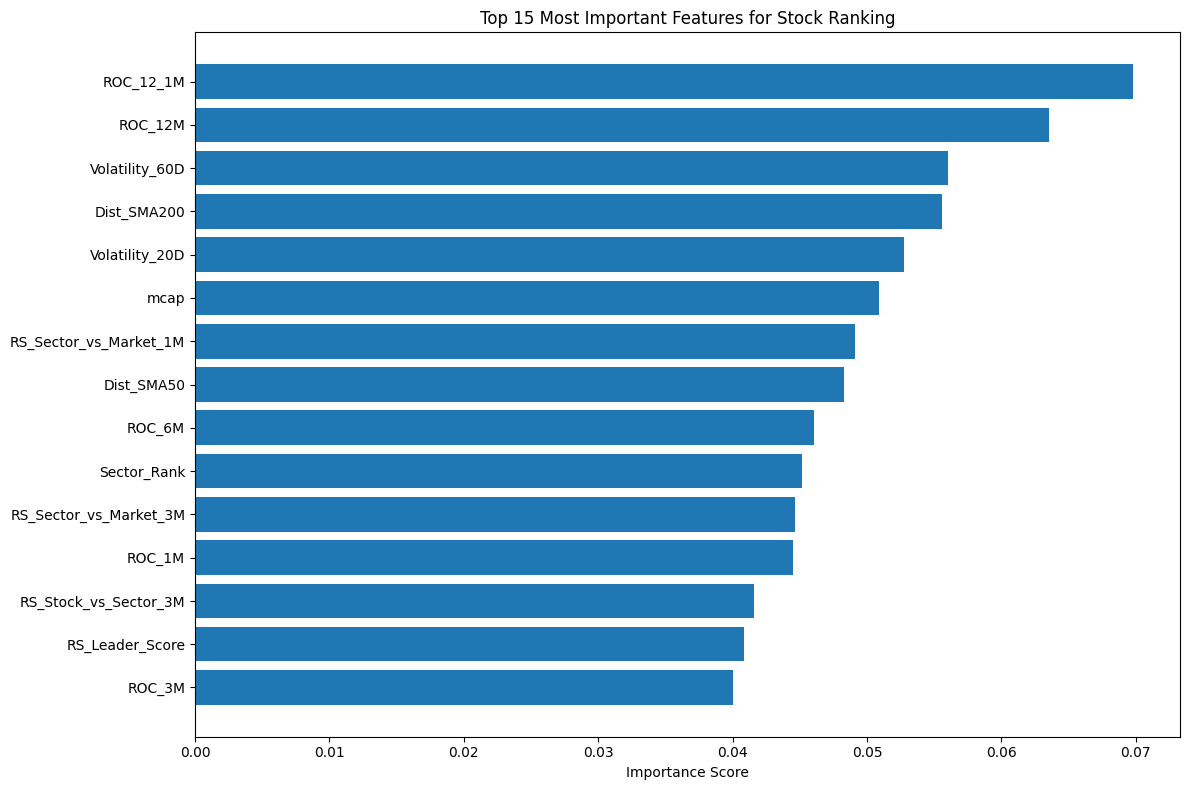


📊 ATS_Trend (Average Trade Size) ranks #13 in importance


In [94]:
def analyze_feature_importance(model, feature_names):
    """
    Analyze and visualize which features the model considers most important
    """
    print("="*70)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*70)

    # Get feature importance
    importance = model.feature_importances_

    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    # Calculate cumulative importance
    importance_df['Cumulative'] = importance_df['Importance'].cumsum() / importance_df['Importance'].sum()

    print("\nTop 15 Most Important Features:")
    print(importance_df.head(15).to_string(index=False))

    # Visualization
    plt.figure(figsize=(12, 8))

    # Plot top 15 features
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance Score')
    plt.title('Top 15 Most Important Features for Stock Ranking')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Check if ATS_Trend is in top features (key innovation from paper)
    ats_rank = importance_df[importance_df['Feature'] == 'ATS_Trend'].index[0] + 1
    print(f"\n📊 ATS_Trend (Average Trade Size) ranks #{ats_rank} in importance")

    return importance_df

# Analyze feature importance
feature_importance = analyze_feature_importance(model, feature_importance_cols)

In [95]:
def construct_portfolio(predictions_df,
                       max_positions=20,
                       min_positions=15,
                       max_single_weight=0.10,
                       max_sector_weight=0.30):
    """
    Construct portfolio using XGBoost rankings
    - Use volatility-based position sizing (inverse NATR weighting)
    - Apply concentration limits
    """
    print("="*70)
    print("PORTFOLIO CONSTRUCTION")
    print("="*70)

    predictions_df = predictions_df.sort_values(['tradedate', 'ML_Rank']).copy()

    portfolio_holdings = []

    unique_dates = sorted(predictions_df['tradedate'].unique())

    for date in unique_dates:
        date_data = predictions_df[predictions_df['tradedate'] == date].copy()

        # Select top N stocks by ML ranking
        top_stocks = date_data.nsmallest(max_positions, 'ML_Rank').copy()

        if len(top_stocks) < min_positions:
            # Not enough stocks - skip this date (will hold cash)
            continue

        # === VOLATILITY-BASED POSITION SIZING ===
        # Lower volatility → Higher weight
        # Use inverse NATR for weighting

        # Handle missing NATR values
        top_stocks['NATR_14_clean'] = top_stocks['NATR_14'].fillna(top_stocks['NATR_14'].median())

        # Inverse volatility weight
        top_stocks['inverse_vol'] = 1.0 / (top_stocks['NATR_14_clean'] + 0.01)  # Add small constant to avoid division by zero

        # Normalize to sum to 1
        total_inverse_vol = top_stocks['inverse_vol'].sum()
        top_stocks['target_weight'] = top_stocks['inverse_vol'] / total_inverse_vol

        # === APPLY CONCENTRATION LIMITS ===

        # Limit 1: Single stock max weight
        top_stocks['target_weight'] = top_stocks['target_weight'].clip(upper=max_single_weight)

        # Limit 2: Sector concentration
        sector_weights = top_stocks.groupby('gics_sector')['target_weight'].sum()
        over_concentrated_sectors = sector_weights[sector_weights > max_sector_weight].index

        for sector in over_concentrated_sectors:
            sector_mask = top_stocks['gics_sector'] == sector
            sector_stocks = top_stocks[sector_mask].copy()

            # Scale down proportionally
            scale_factor = max_sector_weight / sector_weights[sector]
            top_stocks.loc[sector_mask, 'target_weight'] *= scale_factor

        # Re-normalize weights to sum to 1.0
        top_stocks['target_weight'] = top_stocks['target_weight'] / top_stocks['target_weight'].sum()

        # Store holdings
        holdings = top_stocks[[
            'tradedate', 'fid', 'close', 'target_weight',
            'ML_Score', 'ML_Rank', 'NATR_14', 'gics_sector'  # For later analysis
        ]].copy()

        portfolio_holdings.append(holdings)

    # Combine all holdings
    all_holdings = pd.concat(portfolio_holdings, ignore_index=True)

    print(f"\n✓ Portfolio constructed for {len(unique_dates)} rebalancing dates")
    print(f"\nPortfolio statistics:")
    print(f"  Average positions per rebalance: {all_holdings.groupby('tradedate').size().mean():.1f}")
    print(f"  Average weight per position: {all_holdings['target_weight'].mean():.2%}")
    print(f"  Max single position weight: {all_holdings['target_weight'].max():.2%}")
    print(f"  Min single position weight: {all_holdings['target_weight'].min():.2%}")

    # Sector diversification
    avg_sectors = all_holdings.groupby('tradedate')['gics_sector'].nunique().mean()
    print(f"  Average sectors per portfolio: {avg_sectors:.1f}")

    return all_holdings

# Construct portfolio
portfolio_holdings = construct_portfolio(
    predictions,
    max_positions=6,
    min_positions=1,
    max_single_weight=0.10,
    max_sector_weight=0.30
)

print("\nSample portfolio holdings (first rebalance date):")
first_date = portfolio_holdings['tradedate'].min()
print(portfolio_holdings[portfolio_holdings['tradedate'] == first_date][
    ['fid', 'close', 'target_weight', 'ML_Rank', 'NATR_14', 'gics_sector']
].to_string(index=False))

PORTFOLIO CONSTRUCTION

✓ Portfolio constructed for 2102 rebalancing dates

Portfolio statistics:
  Average positions per rebalance: 6.0
  Average weight per position: 16.67%
  Max single position weight: 25.00%
  Min single position weight: 5.10%
  Average sectors per portfolio: 4.0

Sample portfolio holdings (first rebalance date):
  fid    close  target_weight  ML_Rank  NATR_14  gics_sector
 4301 188.0600         0.1667   1.0000   3.8981      25.0000
24057 249.6500         0.1667   2.0000   4.2102      25.0000
   34 252.0600         0.1667   3.0000   2.5575      15.0000
17211  85.8000         0.1667   4.0000   3.7837      60.0000
20631  67.1500         0.1667   5.0000   3.4252      50.0000
 2567  66.3000         0.1667   6.0000   3.4745      45.0000


In [96]:
def create_rebalancing_schedule(holdings_df, rebalance_frequency='Q'):  # ← CHANGED from 'M' to 'Q'
    """
    Create QUARTERLY rebalancing schedule
    Aligned with 3-month prediction horizon
    
    For each rebalancing date:
    - Determine which stocks to hold for NEXT 3 MONTHS
    - Calculate target weights
    - Prepare for execution on T+1
    """
    print("="*70)
    print("CREATING QUARTERLY REBALANCING SCHEDULE")
    print("="*70)
    
    holdings_df = holdings_df.sort_values('tradedate').copy()
    
    # Get quarter-end dates for rebalancing
    holdings_df['year_quarter'] = holdings_df['tradedate'].dt.to_period('Q')
    
    # For each quarter, take the last available trading day
    quarterly_rebalance = holdings_df.groupby('year_quarter').apply(
        lambda x: x[x['tradedate'] == x['tradedate'].max()]
    ).reset_index(drop=True)
    
    # Add rebalance flag
    quarterly_rebalance['is_rebalance_date'] = True
    
    rebalance_dates = sorted(quarterly_rebalance['tradedate'].unique())
    
    print(f"\nRebalancing schedule created:")
    print(f"  Frequency: QUARTERLY (end of quarter)")
    print(f"  Total rebalances: {len(rebalance_dates)}")
    print(f"  First rebalance: {rebalance_dates[0].date()}")
    print(f"  Last rebalance: {rebalance_dates[-1].date()}")
    
    # Calculate days between rebalances
    days_between = [(rebalance_dates[i+1] - rebalance_dates[i]).days 
                    for i in range(len(rebalance_dates)-1)]
    avg_days = np.mean(days_between)
    
    print(f"  Average days between rebalances: {avg_days:.1f} (~3 months)")
    
    # Show rebalance dates
    print(f"\nRebalance Schedule (first 8 quarters):")
    for i, date in enumerate(rebalance_dates[:8]):
        num_stocks = len(quarterly_rebalance[quarterly_rebalance['tradedate'] == date])
        quarter = pd.Timestamp(date).quarter
        year = pd.Timestamp(date).year
        print(f"  {i+1}. Q{quarter} {year}: {date.date()} - {num_stocks} stocks selected")
    
    if len(rebalance_dates) > 8:
        print(f"  ... ({len(rebalance_dates) - 8} more quarters)")
    
    return quarterly_rebalance, rebalance_dates

# Create QUARTERLY rebalancing schedule
rebalance_holdings, rebalance_dates = create_rebalancing_schedule(
    portfolio_holdings,
    rebalance_frequency='Q'  # ← QUARTERLY
)


print(f"\n✓ Quarterly rebalancing schedule ready")
print(f"\nAlignment verification:")
print(f"  Model predicts: 3-month forward returns")
print(f"  Portfolio holds: ~3 months (quarterly rebalancing)")
print(f"  ✓ ALIGNED!")

CREATING QUARTERLY REBALANCING SCHEDULE

Rebalancing schedule created:
  Frequency: QUARTERLY (end of quarter)
  Total rebalances: 34
  First rebalance: 2011-06-30
  Last rebalance: 2019-09-27
  Average days between rebalances: 91.2 (~3 months)

Rebalance Schedule (first 8 quarters):
  1. Q2 2011: 2011-06-30 - 6 stocks selected
  2. Q3 2011: 2011-09-30 - 6 stocks selected
  3. Q4 2011: 2011-12-30 - 6 stocks selected
  4. Q1 2012: 2012-03-30 - 6 stocks selected
  5. Q2 2012: 2012-06-29 - 6 stocks selected
  6. Q3 2012: 2012-09-28 - 6 stocks selected
  7. Q4 2012: 2012-12-31 - 6 stocks selected
  8. Q1 2013: 2013-03-28 - 6 stocks selected
  ... (26 more quarters)

✓ Quarterly rebalancing schedule ready

Alignment verification:
  Model predicts: 3-month forward returns
  Portfolio holds: ~3 months (quarterly rebalancing)
  ✓ ALIGNED!


In [97]:
class PortfolioBacktester:
    """
    Comprehensive backtesting engine
    - Executes trades at T+1 with OHLC average price
    - Applies transaction costs
    - Implements 35% trailing stop loss
    - Tracks daily portfolio NAV
    """

    def __init__(self, initial_capital=5000000, transaction_cost=0.00268):
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost 
        self.cash = initial_capital
        self.positions = {} 
        self.nav_history = []
        self.trade_log = []
        self.daily_holdings = []

    def get_execution_price(self, stock_data):
        """
        Execution price = Average(Open, High, Low, Close) of T+1
        """
        return (stock_data['open'] + stock_data['high'] +
                stock_data['low'] + stock_data['close']) / 4.0

    def calculate_transaction_cost(self, trade_value):
        """
        Apply transaction cost to trade value
        """
        return trade_value * self.transaction_cost

    
    def execute_rebalance(self, target_holdings, next_day_data, rebalance_date):
        """
        Execute portfolio rebalance
        """
        print("\n" + "="*80)
        print(f"EXECUTING REBALANCE ON {rebalance_date.date()}")
        print(f"Execution Date (T+1): {next_day_data['tradedate'].iloc[0].date()}")
        print("="*80)
        
        target_fids = set(target_holdings['fid'].values)
        current_fids = set(self.positions.keys())

        # Get current portfolio value
        portfolio_value = self.cash
        for fid, pos_info in self.positions.items():
            stock_data = next_day_data[next_day_data['fid'] == fid]
            if len(stock_data) > 0:
                current_price = self.get_execution_price(stock_data.iloc[0])
                portfolio_value += pos_info['shares'] * current_price

        print(f"\nPortfolio Value: ₹{portfolio_value:,.0f}")
        print(f"Cash Available: ₹{self.cash:,.0f}")
        print(f"Current Positions: {len(self.positions)}")
        print(f"Target Positions: {len(target_holdings)}")

        # === STEP 1: SELL positions not in target ===
        fids_to_sell = current_fids - target_fids
        
        if len(fids_to_sell) > 0:
            print(f"\n{'─'*80}")
            print(f"SELLING {len(fids_to_sell)} POSITIONS (not in new target)")
            print(f"{'─'*80}")
            print(f"{'FID':<12} {'Shares':<10} {'Price':<12} {'Gross Value':<15} {'TC':<12} {'Net Proceeds':<15}")
            print(f"{'─'*80}")

        for fid in fids_to_sell:
            stock_data = next_day_data[next_day_data['fid'] == fid]
            if len(stock_data) > 0:
                sell_price = self.get_execution_price(stock_data.iloc[0])
                shares = self.positions[fid]['shares']

                # Execute sell
                gross_proceeds = shares * sell_price
                transaction_cost = self.calculate_transaction_cost(gross_proceeds)
                net_proceeds = gross_proceeds - transaction_cost

                self.cash += net_proceeds

                # PRINT TRADE DETAILS:
                print(f"{fid:<12} {shares:<10,} ₹{sell_price:<11,.2f} ₹{gross_proceeds:<14,.0f} ₹{transaction_cost:<11,.0f} ₹{net_proceeds:<14,.0f}")

                # Log trade
                self.trade_log.append({
                    'date': rebalance_date,
                    'execution_date': stock_data.iloc[0]['tradedate'],
                    'fid': fid,
                    'action': 'SELL',
                    'shares': shares,
                    'price': sell_price,
                    'gross_value': gross_proceeds,
                    'transaction_cost': transaction_cost,
                    'net_value': net_proceeds
                })

                # Remove position
                del self.positions[fid]

        # === STEP 2: ADJUST/BUY positions to match target weights ===
        
        buys = []
        adjusts = []
        
        for _, target in target_holdings.iterrows():
            fid = target['fid']
            target_weight = target['target_weight']
            target_value = portfolio_value * target_weight

            stock_data = next_day_data[next_day_data['fid'] == fid]
            if len(stock_data) == 0:
                continue  # Stock not available for trading

            execution_price = self.get_execution_price(stock_data.iloc[0])
            target_shares = int(target_value / execution_price)  # No fractional shares

            if target_shares == 0:
                continue

            current_shares = self.positions.get(fid, {}).get('shares', 0)
            shares_diff = target_shares - current_shares

            if shares_diff != 0:
                action = 'BUY' if shares_diff > 0 else 'SELL'
                trade_shares = abs(shares_diff)

                gross_value = trade_shares * execution_price
                transaction_cost = self.calculate_transaction_cost(gross_value)

                if action == 'BUY':
                    net_cost = gross_value + transaction_cost

                    if net_cost <= self.cash:
                        self.cash -= net_cost

                        # Update position
                        if fid in self.positions:
                            self.positions[fid]['shares'] = target_shares
                            self.positions[fid]['highest_price'] = max(
                                self.positions[fid]['highest_price'], execution_price
                            )
                            # STORE FOR PRINTING (ADJUST):
                            adjusts.append({
                                'fid': fid,
                                'action': 'ADD',
                                'shares': trade_shares,
                                'new_total': target_shares,
                                'price': execution_price,
                                'gross_value': gross_value,
                                'transaction_cost': transaction_cost,
                                'net_value': net_cost,
                                'target_weight': target_weight
                            })
                        else:
                            self.positions[fid] = {
                                'shares': target_shares,
                                'entry_price': execution_price,
                                'highest_price': execution_price
                            }
                            # STORE FOR PRINTING (NEW BUY):
                            buys.append({
                                'fid': fid,
                                'shares': target_shares,
                                'price': execution_price,
                                'gross_value': gross_value,
                                'transaction_cost': transaction_cost,
                                'net_value': net_cost,
                                'target_weight': target_weight
                            })

                        # Log trade
                        self.trade_log.append({
                            'date': rebalance_date,
                            'execution_date': stock_data.iloc[0]['tradedate'],
                            'fid': fid,
                            'action': action,
                            'shares': trade_shares,
                            'price': execution_price,
                            'gross_value': gross_value,
                            'transaction_cost': transaction_cost,
                            'net_value': net_cost
                        })
                else:  # SELL
                    net_proceeds = gross_value - transaction_cost
                    self.cash += net_proceeds

                    if target_shares <= 0:
                        del self.positions[fid]
                    else:
                        self.positions[fid]['shares'] = target_shares

                    # STORE FOR PRINTING (REDUCE):
                    adjusts.append({
                        'fid': fid,
                        'action': 'REDUCE',
                        'shares': trade_shares,
                        'new_total': target_shares,
                        'price': execution_price,
                        'gross_value': gross_value,
                        'transaction_cost': transaction_cost,
                        'net_value': net_proceeds,
                        'target_weight': target_weight
                    })

                    # Log trade
                    self.trade_log.append({
                        'date': rebalance_date,
                        'execution_date': stock_data.iloc[0]['tradedate'],
                        'fid': fid,
                        'action': action,
                        'shares': trade_shares,
                        'price': execution_price,
                        'gross_value': gross_value,
                        'transaction_cost': transaction_cost,
                        'net_value': net_proceeds
                    })

        # PRINT NEW BUYS:
        if len(buys) > 0:
            print(f"\n{'─'*80}")
            print(f"BUYING {len(buys)} NEW POSITIONS")
            print(f"{'─'*80}")
            print(f"{'FID':<12} {'Shares':<10} {'Price':<12} {'Gross Value':<15} {'TC':<12} {'Net Cost':<15} {'Weight %':<10}")
            print(f"{'─'*80}")
            for b in buys:
                print(f"{b['fid']:<12} {b['shares']:<10,} ₹{b['price']:<11,.2f} ₹{b['gross_value']:<14,.0f} ₹{b['transaction_cost']:<11,.0f} ₹{b['net_value']:<14,.0f} {b['target_weight']*100:<9.2f}")

        # PRINT ADJUSTMENTS:
        if len(adjusts) > 0:
            print(f"\n{'─'*80}")
            print(f"ADJUSTING {len(adjusts)} EXISTING POSITIONS")
            print(f"{'─'*80}")
            print(f"{'FID':<12} {'Action':<8} {'Shares':<10} {'New Total':<12} {'Price':<12} {'Value':<15} {'TC':<12} {'Weight %':<10}")
            print(f"{'─'*80}")
            for a in adjusts:
                print(f"{a['fid']:<12} {a['action']:<8} {a['shares']:<10,} {a['new_total']:<12,} ₹{a['price']:<11,.2f} ₹{a['gross_value']:<14,.0f} ₹{a['transaction_cost']:<11,.0f} {a['target_weight']*100:<9.2f}")

        # FINAL SUMMARY:
        print(f"\n{'─'*80}")
        # === REDISTRIBUTE LEFTOVER CASH EQUALLY ===
        if len(self.positions) > 0 and self.cash > 0:

            print(f"\nRedistributing leftover cash: ₹{self.cash:,.0f}")

            active_fids = list(self.positions.keys())
            equal_cash_per_stock = self.cash / len(active_fids)

            for fid in active_fids:
                stock_data = next_day_data[next_day_data['fid'] == fid]
                if len(stock_data) == 0:
                    continue

                execution_price = self.get_execution_price(stock_data.iloc[0])

                # Calculate additional shares affordable
                additional_shares = int(equal_cash_per_stock / execution_price)

                if additional_shares <= 0:
                    continue

                gross_value = additional_shares * execution_price
                transaction_cost = self.calculate_transaction_cost(gross_value)
                total_cost = gross_value + transaction_cost

                if total_cost <= self.cash:

                    self.cash -= total_cost
                    self.positions[fid]['shares'] += additional_shares

                    self.trade_log.append({
                        'date': rebalance_date,
                        'execution_date': stock_data.iloc[0]['tradedate'],
                        'fid': fid,
                        'action': 'CASH_SWEEP_BUY',
                        'shares': additional_shares,
                        'price': execution_price,
                        'gross_value': gross_value,
                        'transaction_cost': transaction_cost,
                        'net_value': total_cost
                    })

                    print(f"  Added {additional_shares} shares to {fid}")
        print(f"REBALANCE COMPLETE")
        print(f"{'─'*80}")
        print(f"Final Cash: ₹{self.cash:,.0f}")
        print(f"Final Positions: {len(self.positions)}")
        total_tc = sum([b['transaction_cost'] for b in buys] + 
                    [a['transaction_cost'] for a in adjusts])
        print(f"Total Transaction Costs: ₹{total_tc:,.0f}")
        print("="*80 + "\n")

    def check_stop_loss(self, current_date, price_data, stop_loss_threshold=0.375):
        fids_to_stop = []
        for fid, pos_info in self.positions.items():
            stock_data = price_data[price_data['fid'] == fid]
            if stock_data.empty: continue
            
            row = stock_data.iloc[0]
            # Use High to update the trailing peak
            if row['high'] > pos_info['highest_price']:
                self.positions[fid]['highest_price'] = row['high']

            # Use Low to see if stop was hit intraday
            drawdown = (pos_info['highest_price'] - row['low']) / pos_info['highest_price']

            if drawdown >= stop_loss_threshold:
                fids_to_stop.append(fid)

        # Execute stop loss sells
        for fid in fids_to_stop:
            stock_data = price_data[price_data['fid'] == fid]
            sell_price = stock_data.iloc[0]['close']
            shares = self.positions[fid]['shares']

            gross_proceeds = shares * sell_price
            transaction_cost = self.calculate_transaction_cost(gross_proceeds)
            net_proceeds = gross_proceeds - transaction_cost

            self.cash += net_proceeds

            # Log stop loss trade
            self.trade_log.append({
                'date': current_date,
                'execution_date': current_date,
                'fid': fid,
                'action': 'STOP_LOSS',
                'shares': shares,
                'price': sell_price,
                'gross_value': gross_proceeds,
                'transaction_cost': transaction_cost,
                'net_value': net_proceeds
            })

            # Remove position
            del self.positions[fid]

        return len(fids_to_stop)

    def calculate_nav(self, current_date, price_data):
        """
        Calculate current NAV (Net Asset Value)
        """
        portfolio_value = self.cash

        position_details = []

        for fid, pos_info in self.positions.items():
            stock_data = price_data[price_data['fid'] == fid]
            if len(stock_data) > 0:
                current_price = stock_data.iloc[0]['close']
                position_value = pos_info['shares'] * current_price
                portfolio_value += position_value

                position_details.append({
                    'fid': fid,
                    'shares': pos_info['shares'],
                    'price': current_price,
                    'value': position_value,
                    'weight': 0  # Will calculate after total known
                })

        # Calculate weights
        for pos in position_details:
            pos['weight'] = pos['value'] / portfolio_value if portfolio_value > 0 else 0

        return portfolio_value, position_details

    def run_backtest(self, rebalance_holdings_df, daily_price_data, rebalance_dates):
        """
        Main backtesting loop
        """
        print("="*70)
        print("RUNNING BACKTEST")
        print("="*70)

        daily_price_data = daily_price_data.sort_values('tradedate')
        all_dates = sorted(daily_price_data['tradedate'].unique())

        print(f"\nBacktest period: {all_dates[0].date()} to {all_dates[-1].date()}")
        print(f"Total trading days: {len(all_dates)}")
        print(f"Rebalance dates: {len(rebalance_dates)}")
        print(f"Initial capital: ₹{self.initial_capital:,.0f}")

        rebalance_idx = 0
        next_rebalance = rebalance_dates[rebalance_idx] if rebalance_idx < len(rebalance_dates) else None

        for i, current_date in enumerate(all_dates):

            # Get price data for current date
            today_data = daily_price_data[daily_price_data['tradedate'] == current_date]

            # Check stop loss daily
            stopped_count = self.check_stop_loss(current_date, today_data)

            # Check if it's a rebalance date
            if next_rebalance and current_date >= next_rebalance:

                # Get target holdings for this rebalance
                target_holdings = rebalance_holdings_df[
                    rebalance_holdings_df['tradedate'] == next_rebalance
                ]

                # Need T+1 data for execution
                if i + 1 < len(all_dates):
                    next_date = all_dates[i + 1]
                    next_day_data = daily_price_data[daily_price_data['tradedate'] == next_date]

                    # Execute rebalance
                    self.execute_rebalance(target_holdings, next_day_data, next_rebalance)

                # Move to next rebalance date
                rebalance_idx += 1
                next_rebalance = rebalance_dates[rebalance_idx] if rebalance_idx < len(rebalance_dates) else None

            # Calculate and store daily NAV
            nav, position_details = self.calculate_nav(current_date, today_data)

            self.nav_history.append({
                'date': current_date,
                'nav': nav,
                'cash': self.cash,
                'num_positions': len(self.positions),
                'stopped_positions': stopped_count
            })

            self.daily_holdings.append({
                'date': current_date,
                'positions': position_details.copy()
            })

            # Progress update
            if (i + 1) % 100 == 0 or (i + 1) == len(all_dates):
                progress = (i + 1) / len(all_dates) * 100
                print(f"  Progress: {progress:.1f}% | Date: {current_date.date()} | NAV: ₹{nav:,.0f} | Positions: {len(self.positions)}", end='\r')

        print(f"\n\n✓ Backtest complete!")

        # Convert to DataFrames
        self.nav_df = pd.DataFrame(self.nav_history)
        self.trades_df = pd.DataFrame(self.trade_log)

        return self.nav_df, self.trades_df

# Initialize backtester
print("\n" + "="*70)
print("INITIALIZING BACKTEST ENGINE")
print("="*70)

backtester = PortfolioBacktester(
    initial_capital=5000000,  # ₹50 lakhs
    transaction_cost=0.00268  # 0.268% per trade, 0.536% round trip
)

# Run backtest
nav_df, trades_df = backtester.run_backtest(
    rebalance_holdings_df=rebalance_holdings,
    daily_price_data=df_processed,
    rebalance_dates=rebalance_dates
)

print(f"\n✓ Backtest results ready")
print(f"  Total transaction costs: ₹{trades_df['transaction_cost'].sum():,.0f}")


INITIALIZING BACKTEST ENGINE
RUNNING BACKTEST

Backtest period: 2009-12-31 to 2020-01-01
Total trading days: 2480
Rebalance dates: 34
Initial capital: ₹5,000,000
  Progress: 12.1% | Date: 2011-03-10 | NAV: ₹5,000,000 | Positions: 0
EXECUTING REBALANCE ON 2011-06-30
Execution Date (T+1): 2011-07-01

Portfolio Value: ₹5,000,000
Cash Available: ₹5,000,000
Current Positions: 0
Target Positions: 6

────────────────────────────────────────────────────────────────────────────────
BUYING 5 NEW POSITIONS
────────────────────────────────────────────────────────────────────────────────
FID          Shares     Price        Gross Value     TC           Net Cost        Weight %  
────────────────────────────────────────────────────────────────────────────────
720          5,424      ₹153.61      ₹833,181        ₹2,233       ₹835,414        16.67    
24057        2,759      ₹301.98      ₹833,149        ₹2,233       ₹835,382        16.67    
21361        1,000      ₹833.25      ₹833,250        ₹2,233

In [98]:
def calculate_performance_metrics(nav_df, benchmark_returns=None):
    """
    Calculate comprehensive performance metrics
    Required by problem statement
    """
    print("="*70)
    print("CALCULATING PERFORMANCE METRICS")
    print("="*70)

    nav_df = nav_df.sort_values('date').copy()

    # Calculate returns
    nav_df['daily_return'] = nav_df['nav'].pct_change()
    nav_df['cumulative_return'] = (nav_df['nav'] / nav_df['nav'].iloc[0]) - 1

    # === CORE METRICS ===

    # Total return
    total_return = (nav_df['nav'].iloc[-1] / nav_df['nav'].iloc[0]) - 1

    # CAGR
    start_date = nav_df['date'].iloc[0]
    end_date = nav_df['date'].iloc[-1]
    years = (end_date - start_date).days / 365.25
    cagr = (((nav_df['nav'].iloc[-1] / nav_df['nav'].iloc[0]) ** (1/years)) - 1)

    # Volatility (annualized)
    daily_vol = nav_df['daily_return'].std()
    annual_vol = daily_vol * np.sqrt(252)

    # Sharpe Ratio (assuming 5% risk-free rate)
    risk_free_rate = 0.05
    excess_return = cagr - risk_free_rate
    sharpe_ratio = excess_return / annual_vol if annual_vol > 0 else 0

    # Sortino Ratio (downside deviation)
    downside_returns = nav_df[nav_df['daily_return'] < 0]['daily_return']
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino_ratio = excess_return / downside_vol if downside_vol > 0 else 0

    # === DRAWDOWN ANALYSIS ===
    nav_df['cumulative_max'] = nav_df['nav'].cummax()
    nav_df['drawdown'] = (nav_df['nav'] - nav_df['cumulative_max']) / nav_df['cumulative_max']

    max_drawdown = nav_df['drawdown'].min()

    # Find max drawdown period
    max_dd_idx = nav_df['drawdown'].idxmin()
    max_dd_date = nav_df.loc[max_dd_idx, 'date']

    # Peak before max drawdown
    peak_before_dd = nav_df.loc[:max_dd_idx, 'cumulative_max'].max()
    peak_idx = nav_df[nav_df['nav'] == peak_before_dd].index[0]
    peak_date = nav_df.loc[peak_idx, 'date']

    # Recovery date (if recovered)
    recovery_data = nav_df.loc[max_dd_idx:]
    recovered = recovery_data[recovery_data['nav'] >= peak_before_dd]
    recovery_date = recovered['date'].iloc[0] if len(recovered) > 0 else None

    # === WIN RATE ===
    winning_days = (nav_df['daily_return'] > 0).sum()
    total_days = len(nav_df[nav_df['daily_return'].notna()])
    win_rate = winning_days / total_days if total_days > 0 else 0

    # === BENCHMARK COMPARISON (if provided) ===
    if benchmark_returns is not None:
        # Information Ratio
        active_returns = nav_df['daily_return'] - benchmark_returns
        tracking_error = active_returns.std() * np.sqrt(252)
        information_ratio = (cagr - benchmark_returns.mean() * 252) / tracking_error if tracking_error > 0 else 0

        # Up/Down Capture
        up_market = benchmark_returns > 0
        down_market = benchmark_returns < 0

        up_capture = (nav_df.loc[up_market, 'daily_return'].mean() /
                     benchmark_returns[up_market].mean()) if up_market.sum() > 0 else 0
        down_capture = (nav_df.loc[down_market, 'daily_return'].mean() /
                       benchmark_returns[down_market].mean()) if down_market.sum() > 0 else 0
    else:
        information_ratio = None
        up_capture = None
        down_capture = None
        tracking_error = None

    # === COMPILE METRICS ===
    metrics = {
        'Total Return': total_return,
        'CAGR': cagr,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_drawdown,
        'Max DD Peak Date': peak_date,
        'Max DD Bottom Date': max_dd_date,
        'Recovery Date': recovery_date,
        'Win Rate (Daily)': win_rate,
        'Information Ratio': information_ratio,
        'Up Capture': up_capture,
        'Down Capture': down_capture,
        'Tracking Error': tracking_error,
        'Total Days': total_days,
        'Years': years
    }

    # === PRINT METRICS ===
    print(f"\n{'='*50}")
    print(f"PERFORMANCE SUMMARY ({start_date.date()} to {end_date.date()})")
    print(f"{'='*50}")
    print(f"\nRETURN METRICS:")
    print(f"  Total Return:        {total_return:>10.2%}")
    print(f"  CAGR:                {cagr:>10.2%}")
    print(f"  Annual Volatility:   {annual_vol:>10.2%}")

    print(f"\nRISK-ADJUSTED RETURNS:")
    print(f"  Sharpe Ratio:        {sharpe_ratio:>10.2f}")
    print(f"  Sortino Ratio:       {sortino_ratio:>10.2f}")

    print(f"\nDRAWDOWN ANALYSIS:")
    print(f"  Maximum Drawdown:    {max_drawdown:>10.2%}")
    print(f"  Peak Date:           {peak_date.date()}")
    print(f"  Bottom Date:         {max_dd_date.date()}")
    if recovery_date:
        print(f"  Recovery Date:       {recovery_date.date()}")
        recovery_days = (recovery_date - max_dd_date).days
        print(f"  Recovery Time:       {recovery_days} days")
    else:
        print(f"  Recovery Date:       Not recovered")

    print(f"\nTRADING STATISTICS:")
    print(f"  Win Rate (Daily):    {win_rate:>10.2%}")
    print(f"  Total Trading Days:  {total_days:>10,}")

    if information_ratio is not None:
        print(f"\nBENCHMARK COMPARISON:")
        print(f"  Information Ratio:   {information_ratio:>10.2f}")
        print(f"  Tracking Error:      {tracking_error:>10.2%}")
        print(f"  Up Capture:          {up_capture:>10.2%}")
        print(f"  Down Capture:        {down_capture:>10.2%}")

    return metrics, nav_df

# Calculate performance metrics
metrics, nav_with_metrics = calculate_performance_metrics(nav_df)

CALCULATING PERFORMANCE METRICS

PERFORMANCE SUMMARY (2009-12-31 to 2020-01-01)

RETURN METRICS:
  Total Return:          8180.02%
  CAGR:                    55.52%
  Annual Volatility:       21.84%

RISK-ADJUSTED RETURNS:
  Sharpe Ratio:              2.31
  Sortino Ratio:             3.29

DRAWDOWN ANALYSIS:
  Maximum Drawdown:       -25.05%
  Peak Date:           2015-07-13
  Bottom Date:         2016-11-21
  Recovery Date:       2017-04-25
  Recovery Time:       155 days

TRADING STATISTICS:
  Win Rate (Daily):        47.84%
  Total Trading Days:       2,479


In [99]:
def create_benchmark_proxy(df_processed):
    """
    Create a synthetic Nifty 500 benchmark using equal-weighted NSE500 constituents
    """
    print("="*70)
    print("CREATING NIFTY 500 PROXY BENCHMARK")
    print("="*70)

    # Filter for NSE500 constituents only
    nse500_stocks = df_processed[df_processed['in_NSE500'] == True].copy()

    # Calculate equal-weighted daily returns
    benchmark = nse500_stocks.groupby('tradedate').agg({
        'daily_return': 'mean',  # Equal-weighted average
        'fid': 'count'
    }).reset_index()

    benchmark.columns = ['date', 'daily_return', 'num_stocks']
    benchmark['daily_return'] = benchmark['daily_return'].fillna(0)

    # Calculate cumulative index value (starting at 5,000,000 for comparison)
    benchmark['index_value'] = 5000000 * (1 + benchmark['daily_return']).cumprod()

    print(f"\nBenchmark statistics:")
    print(f"  Start date: {benchmark['date'].min().date()}")
    print(f"  End date: {benchmark['date'].max().date()}")
    print(f"  Trading days: {len(benchmark)}")
    print(f"  Avg stocks per day: {benchmark['num_stocks'].mean():.0f}")

    # Calculate benchmark performance
    total_return = (benchmark['index_value'].iloc[-1] / benchmark['index_value'].iloc[0]) - 1
    
    # Safe date difference calculation
    days = (benchmark['date'].iloc[-1] - benchmark['date'].iloc[0]).days
    years = days / 365.25 if days > 0 else 1 
    
    cagr = ((benchmark['index_value'].iloc[-1] / benchmark['index_value'].iloc[0]) ** (1/years)) - 1
    volatility = benchmark['daily_return'].std() * np.sqrt(252)

    print(f"\nBenchmark Performance:")
    print(f"  Total Return: {total_return:.2%}")
    print(f"  Annualised Return (CAGR): {cagr:.2%}")
    print(f"  Volatility: {volatility:.2%}")

    return benchmark

# Create benchmark
benchmark_df = create_benchmark_proxy(df_processed)

# Recalculate strategy performance with benchmark comparison
print("\n" + "="*70)
print("STRATEGY VS BENCHMARK COMPARISON")
print("="*70)

# Merge strategy and benchmark
comparison_df = nav_with_metrics[['date', 'nav', 'daily_return']].merge(
    benchmark_df[['date', 'index_value', 'daily_return']],
    on='date',
    how='inner',
    suffixes=('_strategy', '_benchmark')
)

comparison_df['daily_return_strategy'] = comparison_df['daily_return_strategy'].fillna(0)
comparison_df['daily_return_benchmark'] = comparison_df['daily_return_benchmark'].fillna(0)

# Calculate metrics with benchmark
strategy_total_return = (comparison_df['nav'].iloc[-1] / comparison_df['nav'].iloc[0]) - 1
benchmark_total_return = (comparison_df['index_value'].iloc[-1] / comparison_df['index_value'].iloc[0]) - 1
outperformance = strategy_total_return - benchmark_total_return

days = (comparison_df['date'].iloc[-1] - comparison_df['date'].iloc[0]).days
years = days / 365.25 if days > 0 else 1

strategy_cagr = ((comparison_df['nav'].iloc[-1] / comparison_df['nav'].iloc[0]) ** (1/years)) - 1
benchmark_cagr = ((comparison_df['index_value'].iloc[-1] / comparison_df['index_value'].iloc[0]) ** (1/years)) - 1
cagr_outperformance = strategy_cagr - benchmark_cagr

# Information Ratio
active_returns = comparison_df['daily_return_strategy'] - comparison_df['daily_return_benchmark']
tracking_error = active_returns.std() * np.sqrt(252)
information_ratio = (strategy_cagr - benchmark_cagr) / tracking_error if tracking_error > 0 else 0

# Up/Down Capture
up_market = comparison_df['daily_return_benchmark'] > 0
down_market = comparison_df['daily_return_benchmark'] < 0

up_capture = (comparison_df.loc[up_market, 'daily_return_strategy'].mean() /
              comparison_df.loc[up_market, 'daily_return_benchmark'].mean()) if up_market.sum() > 0 else 0
down_capture = (comparison_df.loc[down_market, 'daily_return_strategy'].mean() /
                comparison_df.loc[down_market, 'daily_return_benchmark'].mean()) if down_market.sum() > 0 else 0

print(f"\nCOMPARATIVE PERFORMANCE:")
print(f"{'Metric':<30} {'Strategy':>15} {'Benchmark':>15} {'Difference':>15}")
print(f"{'-'*75}")
print(f"{'Total Return':<30} {strategy_total_return:>14.2%} {benchmark_total_return:>14.2%} {outperformance:>14.2%}")
print(f"{'Annualised Return (CAGR)':<30} {strategy_cagr:>14.2%} {benchmark_cagr:>14.2%} {cagr_outperformance:>14.2%}")

strategy_vol = comparison_df['daily_return_strategy'].std() * np.sqrt(252)
benchmark_vol = comparison_df['daily_return_benchmark'].std() * np.sqrt(252)
print(f"{'Volatility':<30} {strategy_vol:>14.2%} {benchmark_vol:>14.2%} {strategy_vol-benchmark_vol:>14.2%}")

print(f"\n{'Information Ratio':<30} {information_ratio:>14.2f}")
print(f"{'Tracking Error':<30} {tracking_error:>14.2%}")
print(f"{'Up Capture':<30} {up_capture:>14.2%}")
print(f"{'Down Capture':<30} {down_capture:>14.2%}")


CREATING NIFTY 500 PROXY BENCHMARK

Benchmark statistics:
  Start date: 2009-12-31
  End date: 2020-01-01
  Trading days: 2480
  Avg stocks per day: 500

Benchmark Performance:
  Total Return: 95.50%
  Annualised Return (CAGR): 6.93%
  Volatility: 16.40%

STRATEGY VS BENCHMARK COMPARISON

COMPARATIVE PERFORMANCE:
Metric                                Strategy       Benchmark      Difference
---------------------------------------------------------------------------
Total Return                         8180.02%         95.50%       8084.51%
Annualised Return (CAGR)               55.52%          6.93%         48.58%
Volatility                             21.84%         16.40%          5.44%

Information Ratio                        2.69
Tracking Error                         18.05%
Up Capture                            102.67%
Down Capture                           61.27%


In [100]:
def calculate_rolling_performance(nav_df, benchmark_df=None):
    """
    Calculate rolling performance metrics as required by problem statement:
    - 1 Year rolling
    - 3 Year rolling
    - 5 Year rolling

    For each window: Average Outperformance & Worst Underperformance vs Nifty 500

    """
    print("="*70)
    print("CALCULATING ROLLING PERFORMANCE METRICS")
    print("="*70)

    nav_df = nav_df.sort_values('date').copy()

    # Calculate daily returns if not already present
    if 'daily_return' not in nav_df.columns:
        nav_df['daily_return'] = nav_df['nav'].pct_change()

    # Define rolling windows
    windows = {
        '1Y': 252,   # ~1 year trading days
        '3Y': 756,   # ~3 years trading days
        '5Y': 1260   # ~5 years trading days
    }

    rolling_metrics = {}

    # Merge benchmark once outside the loop to align dates perfectly
    temp_calc_df = nav_df[['date', 'nav']].copy()
    if benchmark_df is not None:
        temp_calc_df = temp_calc_df.merge(benchmark_df[['date', 'index_value']], on='date', how='left')

    for window_name, window_days in windows.items():
        print(f"\nCalculating {window_name} rolling metrics...")

        # 1. Use vectorized pct_change instead of slow row-by-row looping
        temp_calc_df['return'] = temp_calc_df['nav'].pct_change(periods=window_days)
        
        # 2. Annualize the return
        years = window_days / 252
        temp_calc_df['annualized_return'] = ((1 + temp_calc_df['return']) ** (1/years)) - 1
        
        # 3. Handle Benchmark Outperformance correctly
        if benchmark_df is not None:
            temp_calc_df['bench_return'] = temp_calc_df['index_value'].pct_change(periods=window_days)
            temp_calc_df['bench_annualized'] = ((1 + temp_calc_df['bench_return']) ** (1/years)) - 1
            # True outperformance = Strategy - Benchmark
            temp_calc_df['outperformance'] = temp_calc_df['annualized_return'] - temp_calc_df['bench_annualized']
        else:
            # Without benchmark, absolute return is used as placeholder
            temp_calc_df['outperformance'] = temp_calc_df['annualized_return']

        rolling_df = temp_calc_df.dropna(subset=['annualized_return']).copy()
        rolling_df = rolling_df.rename(columns={'date': 'end_date'})

        if len(rolling_df) > 0:
            avg_outperformance = rolling_df['outperformance'].mean()
            worst_underperformance = rolling_df['outperformance'].min()

            rolling_metrics[window_name] = {
                'rolling_data': rolling_df,
                'average_return': rolling_df['annualized_return'].mean(),
                'median_return': rolling_df['annualized_return'].median(),
                'best_return': rolling_df['annualized_return'].max(),
                'worst_return': rolling_df['annualized_return'].min(),
                'std_return': rolling_df['annualized_return'].std(),
                'positive_periods': (rolling_df['annualized_return'] > 0).sum(),
                'total_periods': len(rolling_df),
                'avg_outperformance': avg_outperformance,
                'worst_underperformance': worst_underperformance
            }

            print(f"  {window_name} Rolling Windows: {len(rolling_df)}")
            print(f"  Average Outperformance: {avg_outperformance:.2%}")
            print(f"  Best Return: {rolling_df['annualized_return'].max():.2%}")
            print(f"  Worst Underperformance: {worst_underperformance:.2%}")
            print(f"  Positive Periods: {(rolling_df['annualized_return'] > 0).sum()}/{len(rolling_df)}")
        else:
            print(f"  Insufficient data for {window_name} rolling calculation")
            rolling_metrics[window_name] = None

    print(f"\n{'='*70}")
    print(f"ROLLING PERFORMANCE SUMMARY TABLE")
    print(f"{'='*70}")

    summary_data = []
    for window_name in ['1Y', '3Y', '5Y']:
        if window_name in rolling_metrics and rolling_metrics[window_name] is not None:
            metrics = rolling_metrics[window_name]
            summary_data.append({
                'Window': window_name,
                'Average Outperformance': f"{metrics['avg_outperformance']:.2%}",
                'Worst Underperformance': f"{metrics['worst_underperformance']:.2%}",
                'Best Return': f"{metrics['best_return']:.2%}",
                'Win Rate': f"{metrics['positive_periods']}/{metrics['total_periods']} ({metrics['positive_periods']/metrics['total_periods']*100:.1f}%)"
            })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

    return rolling_metrics, summary_df

rolling_metrics, rolling_summary = calculate_rolling_performance(nav_with_metrics, benchmark_df)

CALCULATING ROLLING PERFORMANCE METRICS

Calculating 1Y rolling metrics...
  1Y Rolling Windows: 2228
  Average Outperformance: 62.41%
  Best Return: 237.16%
  Worst Underperformance: -36.56%
  Positive Periods: 1949/2228

Calculating 3Y rolling metrics...
  3Y Rolling Windows: 1724
  Average Outperformance: 59.26%
  Best Return: 147.06%
  Worst Underperformance: 15.92%
  Positive Periods: 1724/1724

Calculating 5Y rolling metrics...
  5Y Rolling Windows: 1220
  Average Outperformance: 57.29%
  Best Return: 95.64%
  Worst Underperformance: 32.74%
  Positive Periods: 1220/1220

ROLLING PERFORMANCE SUMMARY TABLE
Window Average Outperformance Worst Underperformance Best Return           Win Rate
    1Y                 62.41%                -36.56%     237.16%  1949/2228 (87.5%)
    3Y                 59.26%                 15.92%     147.06% 1724/1724 (100.0%)
    5Y                 57.29%                 32.74%      95.64% 1220/1220 (100.0%)


GENERATING PERFORMANCE CHARTS


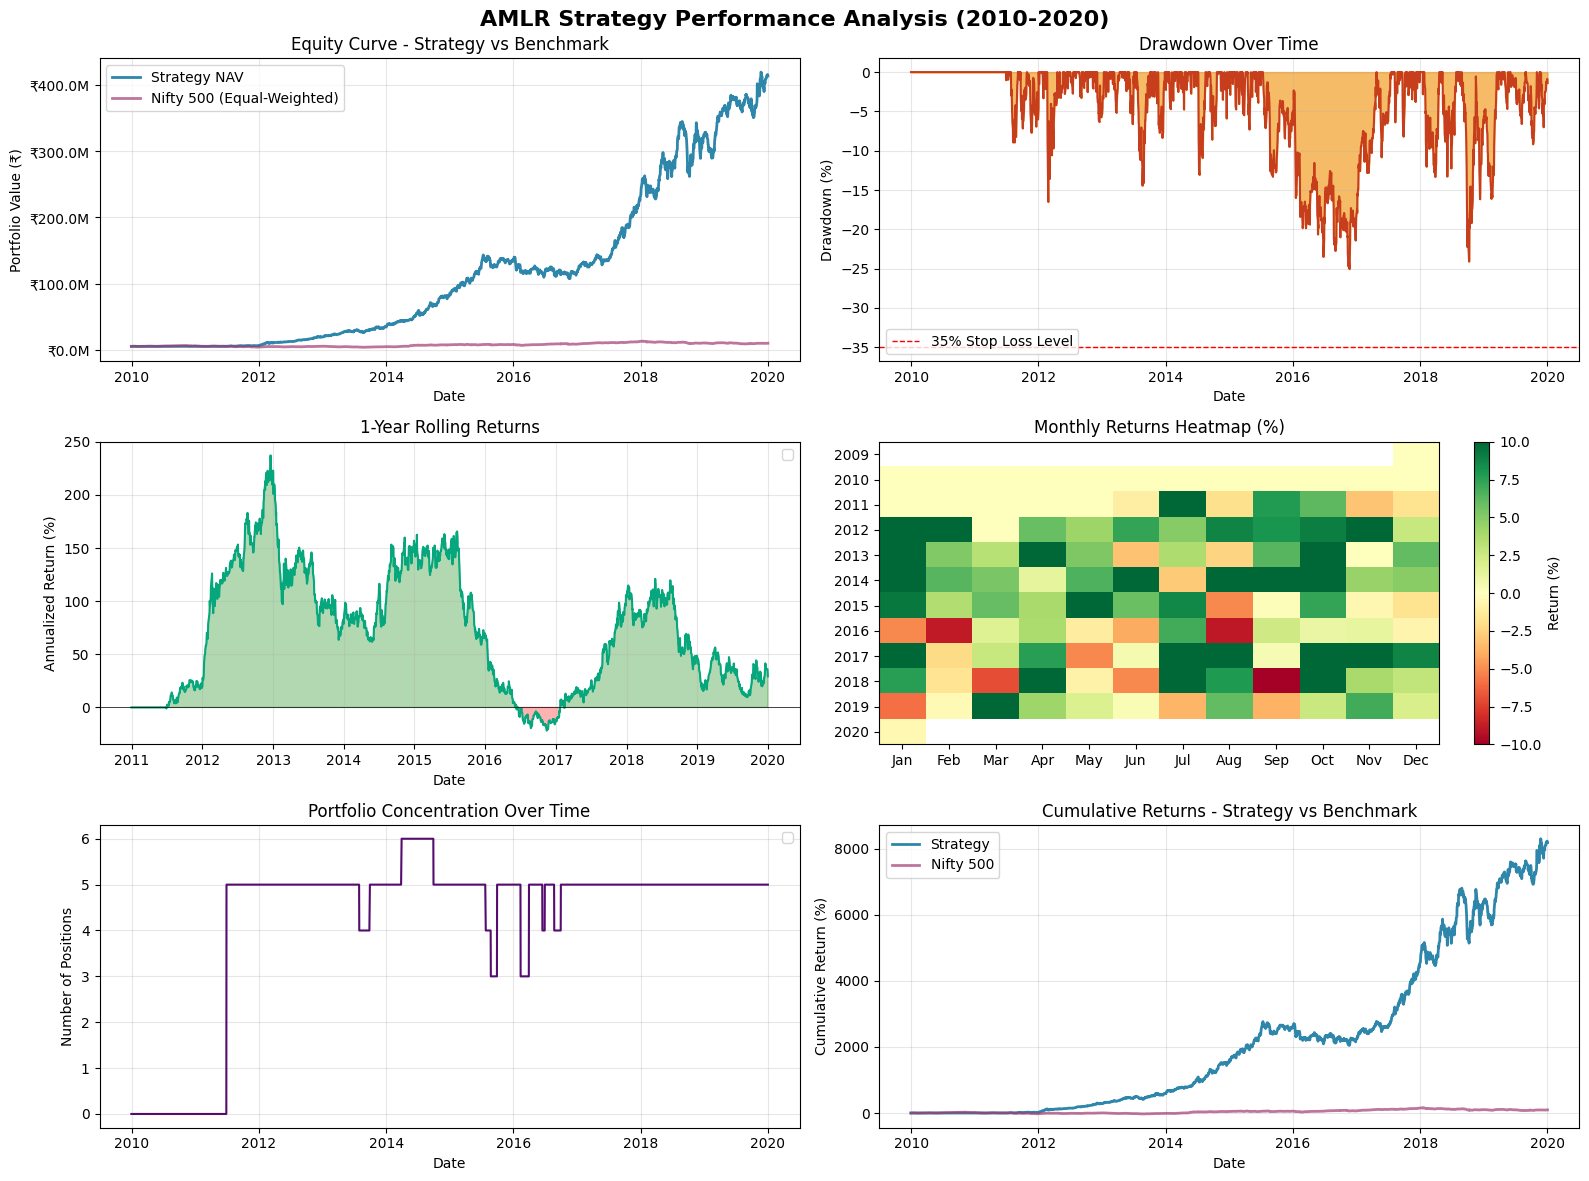


✓ Charts generated


In [101]:
def plot_performance_charts(nav_df, benchmark_df=None, comparison_df=None):
    """
    Create comprehensive performance visualizations
    """
    print("="*70)
    print("GENERATING PERFORMANCE CHARTS")
    print("="*70)

    # Create figure with subplots
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('AMLR Strategy Performance Analysis (2010-2020)', fontsize=16, fontweight='bold')

    # === 1. NAV Curve ===
    ax1 = axes[0, 0]
    ax1.plot(nav_df['date'], nav_df['nav'], label='Strategy NAV', linewidth=2, color='#2E86AB')
    if benchmark_df is not None and comparison_df is not None:
        ax1.plot(comparison_df['date'], comparison_df['index_value'],
                label='Nifty 500 (Equal-Weighted)', linewidth=2, color='#A23B72', alpha=0.7)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Portfolio Value (₹)')
    ax1.set_title('Equity Curve - Strategy vs Benchmark')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M'))

    # === 2. Drawdown Curve ===
    ax2 = axes[0, 1]
    ax2.fill_between(nav_df['date'], nav_df['drawdown'] * 100, 0,
                     color='#F18F01', alpha=0.6)
    ax2.plot(nav_df['date'], nav_df['drawdown'] * 100, color='#C73E1D', linewidth=1.5)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_title('Drawdown Over Time')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=-35, color='red', linestyle='--', linewidth=1, label='35% Stop Loss Level')
    ax2.legend()

    # === 3. Rolling Returns (1Y) ===
    if '1Y' in rolling_metrics and rolling_metrics['1Y'] is not None:
        ax3 = axes[1, 0]
        rolling_1y = rolling_metrics['1Y']['rolling_data']
        ax3.plot(rolling_1y['end_date'], rolling_1y['annualized_return'] * 100,
                linewidth=1.5, color='#06A77D')
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax3.fill_between(rolling_1y['end_date'], 0, rolling_1y['annualized_return'] * 100,
                        where=(rolling_1y['annualized_return'] > 0), alpha=0.3, color='green')
        ax3.fill_between(rolling_1y['end_date'], 0, rolling_1y['annualized_return'] * 100,
                        where=(rolling_1y['annualized_return'] <= 0), alpha=0.3, color='red')
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Annualized Return (%)')
        ax3.set_title('1-Year Rolling Returns')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

    # === 4. Monthly Returns Heatmap ===
    ax4 = axes[1, 1]
    nav_df['year'] = nav_df['date'].dt.year
    nav_df['month'] = nav_df['date'].dt.month

    monthly_returns = nav_df.groupby(['year', 'month'])['daily_return'].apply(
        lambda x: (1 + x).prod() - 1
    ).reset_index()
    monthly_returns.columns = ['year', 'month', 'return']

    # Pivot for heatmap
    heatmap_data = monthly_returns.pivot(index='year', columns='month', values='return')

    im = ax4.imshow(heatmap_data.values * 100, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
    ax4.set_xticks(range(12))
    ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax4.set_yticks(range(len(heatmap_data)))
    ax4.set_yticklabels(heatmap_data.index)
    ax4.set_title('Monthly Returns Heatmap (%)')
    plt.colorbar(im, ax=ax4, label='Return (%)')

    # === 5. Number of Positions Over Time ===
    ax5 = axes[2, 0]
    ax5.plot(nav_df['date'], nav_df['num_positions'], linewidth=1.5, color='#540D6E')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Number of Positions')
    ax5.set_title('Portfolio Concentration Over Time')
    ax5.grid(True, alpha=0.3)
    ax5.legend()

    # === 6. Cumulative Returns Comparison ===
    ax6 = axes[2, 1]
    nav_df['cumulative_pct'] = (nav_df['nav'] / nav_df['nav'].iloc[0] - 1) * 100
    ax6.plot(nav_df['date'], nav_df['cumulative_pct'],
            label='Strategy', linewidth=2, color='#2E86AB')

    if benchmark_df is not None and comparison_df is not None:
        comparison_df['benchmark_cumulative_pct'] = (
            comparison_df['index_value'] / comparison_df['index_value'].iloc[0] - 1
        ) * 100
        ax6.plot(comparison_df['date'], comparison_df['benchmark_cumulative_pct'],
                label='Nifty 500', linewidth=2, color='#A23B72', alpha=0.7)

    ax6.set_xlabel('Date')
    ax6.set_ylabel('Cumulative Return (%)')
    ax6.set_title('Cumulative Returns - Strategy vs Benchmark')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n✓ Charts generated")

# Generate charts
plot_performance_charts(nav_with_metrics, benchmark_df, comparison_df)

PORTFOLIO TURNOVER ANALYSIS

Turnover Statistics:
  Average one-way turnover per event: 66.36%
  Median turnover: 74.60%
  Max turnover: 93.29%
  Total value traded: ₹6,617,569,157

Transaction Cost Analysis:
  Total transaction costs: ₹19,202,180
  As % of total traded value: 0.268%
  As % of final NAV: 4.64%

Stop Loss Statistics:
  Total stop loss events: 7
  Stop loss value: ₹115,451,724
  % of all trades: 1.6%

Position Changes:
  Total buy transactions: 152
  Total sell transactions: 160
  Avg trades per event: 11.3


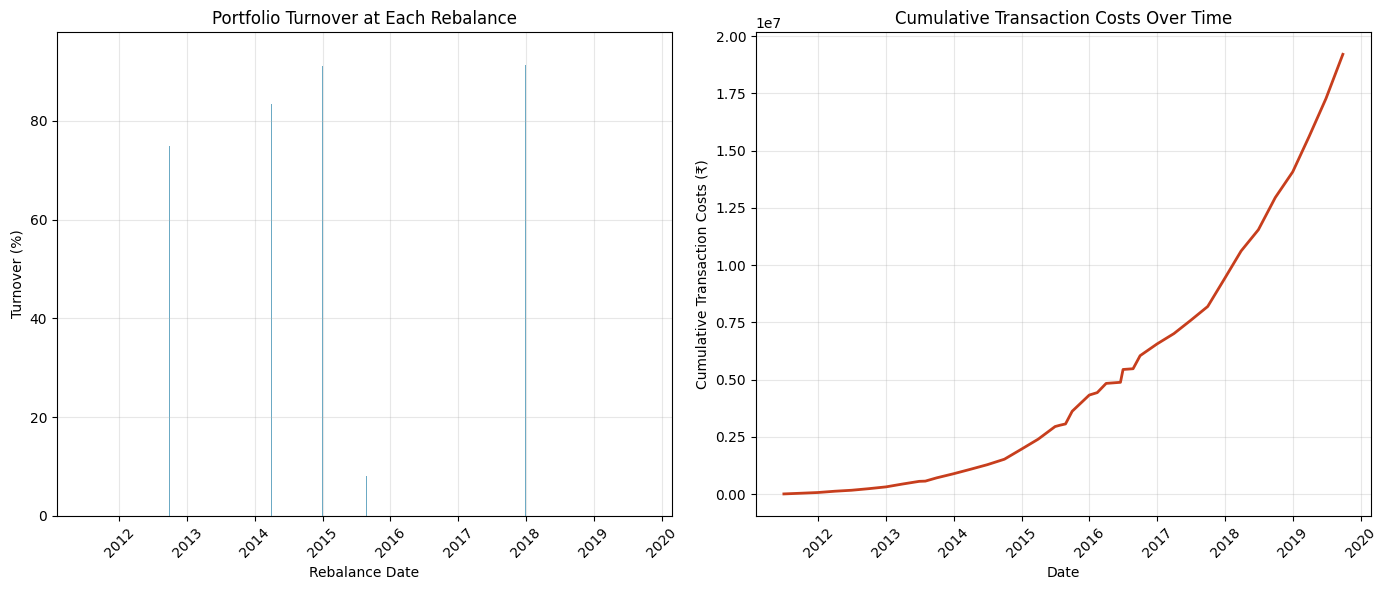

In [102]:

def analyze_portfolio_turnover(trades_df, nav_df):
    """
    Analyze portfolio turnover and trading characteristics
    """
    print("="*70)
    print("PORTFOLIO TURNOVER ANALYSIS")
    print("="*70)

    trades_df = trades_df.copy()
    
    # Ensure datetime format to prevent safe indexing errors
    trades_df['date'] = pd.to_datetime(trades_df['date'])
    
    # Create a safe copy of NAV to avoid SettingWithCopy warnings
    nav_df_safe = nav_df.copy()
    nav_df_safe['date'] = pd.to_datetime(nav_df_safe['date'])

    # Calculate turnover by rebalance date
    rebalance_turnover = []

    for date in trades_df['date'].unique():
        date_trades = trades_df[trades_df['date'] == date]

        # FIX 1: Total traded value must include ALL sell types (Standard Sells, Stop Losses, and Regime Liquidations)
        buy_value = date_trades[date_trades['action'] == 'BUY']['gross_value'].sum()
        sell_value = date_trades[date_trades['action'].isin(['SELL', 'STOP_LOSS', 'RISK_OFF'])]['gross_value'].sum()
        total_traded = buy_value + sell_value

        # Portfolio value at this date
        valid_navs = nav_df_safe[nav_df_safe['date'] <= date]
        nav_at_date = valid_navs['nav'].iloc[-1] if len(valid_navs) > 0 else 1.0

        # FIX 3: Standard One-Way Turnover = Total Traded / 2 / NAV
        turnover_pct = (total_traded / (2 * nav_at_date)) if nav_at_date > 0 else 0

        rebalance_turnover.append({
            'date': date,
            'buy_value': buy_value,
            'sell_value': sell_value,
            'total_traded': total_traded,
            'portfolio_value': nav_at_date,
            'turnover_pct': turnover_pct
        })

    turnover_df = pd.DataFrame(rebalance_turnover)

    print(f"\nTurnover Statistics:")
    print(f"  Average one-way turnover per event: {turnover_df['turnover_pct'].mean():.2%}")
    print(f"  Median turnover: {turnover_df['turnover_pct'].median():.2%}")
    print(f"  Max turnover: {turnover_df['turnover_pct'].max():.2%}")
    print(f"  Total value traded: ₹{turnover_df['total_traded'].sum():,.0f}")

    # Transaction cost analysis
    total_transaction_costs = trades_df['transaction_cost'].sum()
    total_gross_value = trades_df['gross_value'].sum()
    avg_cost_rate = total_transaction_costs / total_gross_value if total_gross_value > 0 else 0

    print(f"\nTransaction Cost Analysis:")
    print(f"  Total transaction costs: ₹{total_transaction_costs:,.0f}")
    print(f"  As % of total traded value: {avg_cost_rate:.3%}")
    print(f"  As % of final NAV: {total_transaction_costs/nav_df_safe['nav'].iloc[-1]:.2%}")

    # Stop loss analysis
    stop_loss_trades = trades_df[trades_df['action'] == 'STOP_LOSS']
    total_trades_count = len(trades_df)
    pct_stop_loss = (len(stop_loss_trades) / total_trades_count * 100) if total_trades_count > 0 else 0
    
    print(f"\nStop Loss Statistics:")
    print(f"  Total stop loss events: {len(stop_loss_trades)}")
    print(f"  Stop loss value: ₹{stop_loss_trades['gross_value'].sum():,.0f}")
    print(f"  % of all trades: {pct_stop_loss:.1f}%")

    # Holding period analysis
    print(f"\nPosition Changes:")
    print(f"  Total buy transactions: {len(trades_df[trades_df['action'] == 'BUY'])}")
    print(f"  Total sell transactions: {len(trades_df[trades_df['action'].isin(['SELL', 'STOP_LOSS', 'RISK_OFF'])])}")
    
    # FIX 2: Derive number of events directly from the trades data to avoid NameError crash
    num_trade_events = len(turnover_df)
    avg_trades = total_trades_count / num_trade_events if num_trade_events > 0 else 0
    print(f"  Avg trades per event: {avg_trades:.1f}")

    return turnover_df

# Analyze turnover
turnover_analysis = analyze_portfolio_turnover(trades_df, nav_with_metrics)

# Plot turnover over time
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.bar(turnover_analysis['date'], turnover_analysis['turnover_pct'] * 100,
        color='#2E86AB', alpha=0.7)
plt.xlabel('Rebalance Date')
plt.ylabel('Turnover (%)')
plt.title('Portfolio Turnover at Each Rebalance')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_costs = trades_df.groupby('date')['transaction_cost'].sum().cumsum()
plt.plot(cumulative_costs.index, cumulative_costs.values, linewidth=2, color='#C73E1D')
plt.xlabel('Date')
plt.ylabel('Cumulative Transaction Costs (₹)')
plt.title('Cumulative Transaction Costs Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()